# 1. Mount Google Drive (import)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Clone phishlang repo & install requirements”.

In [ ]:
%cd /content
!git clone https://github.com/UTA-SPRLab/phishlang.git
%cd phishlang
!pip install -r src/requirements.txt

/content
fatal: destination path 'phishlang' already exists and is not an empty directory.
/content/phishlang


In [ ]:
from transformers import MobileBertForSequenceClassification, MobileBertTokenizer
tokenizer = MobileBertTokenizer.from_pretrained("google/mobilebert-uncased", token=False, clean_up_tokenization_spaces=False)


In [ ]:
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu
!pip install transformers>=4.41.0  # Upgraded transformers to be compatible with sentence-transformers
!pip install datasets
!pip install scikit-learn
!pip install tqdm
!pip install pandas

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu


In [ ]:
%cd /content/phishlang
%pip install -qU "transformers==4.42.4" "tokenizers==0.19.1" "accelerate>=0.30.0" "huggingface-hub>=0.25.0" "numpy>=1.26"

/content/phishlang
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.7/374.7 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 37.9 MB/s eta 0:00:00


# 3. Environment check — library versions + CUDA

In [ ]:
import importlib, torch

def ver(name, mod=None):
    try:
        m = importlib.import_module(mod or name)
        return getattr(m, "__version__", "n/a")
    except Exception:
        return "not installed"

print("transformers:", ver("transformers"))
print("tokenizers:",  ver("tokenizers"))
print("accelerate:",  ver("accelerate"))
print("torch:",       torch.__version__)
print("sentence_transformers:", ver("sentence_transformers"))  # remove if unused
print("CUDA:", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

transformers: 4.44.0
tokenizers: 0.19.1
accelerate: 0.33.0
torch: 2.8.0+cpu
sentence_transformers: not installed
CUDA: False cpu


# 4. Combine training_data parts → zip

In [ ]:
# Navigate to training_data folder
%cd /content/drive/MyDrive/assignment/training_data

# Combine the training data parts into one file (as per original README)
!cat parsed_samples_part_* > parsed_samples_combined.zip

# Check the result
!ls -la parsed_samples_combined.zip

/content/drive/MyDrive/assignment/training_data
-rw------- 1 root root 343680227 Aug 23 07:14 parsed_samples_combined.zip


# 5. Install Python packages

In [ ]:
!apt-get install build-essential
!pip install -U setuptools wheel

In [ ]:
!python3 /content/drive/MyDrive/assignment/src/training.py full

# 6. Code cell

In [ ]:
# --- paths & imports ---
import os, json, re, math
from zipfile import ZipFile
from io import TextIOWrapper
from urllib.parse import urlparse

import numpy as np
import pandas as pd

OUTER_ZIP = "/content/drive/MyDrive/assignment/training_data/parsed_samples_combined.zip"  # <- your file
WORK_DIR  = "/content/parsed_work"  # temp workspace
os.makedirs(WORK_DIR, exist_ok=True)

# --- extract inner ZIPs from the outer ZIP and then extract their CSVs ---
inner_dirs = []  # will hold two folders: /content/parsed_work/parsed_phish_samples and .../parsed_benign_samples

with ZipFile(OUTER_ZIP) as outer:
    inner_zip_names = [n for n in outer.namelist() if n.lower().endswith(".zip")]
    if not inner_zip_names:
        raise RuntimeError("No inner ZIPs found inside parsed_samples_combined.zip")
    print("Found inner ZIPs:", inner_zip_names)

    for name in inner_zip_names:
        # Save inner zip to disk
        inner_zip_path = os.path.join(WORK_DIR, os.path.basename(name))
        with open(inner_zip_path, "wb") as f:
            f.write(outer.read(name))

        # Extract inner zip to a folder named after the zip (minus .zip)
        out_folder = os.path.join(WORK_DIR, os.path.splitext(os.path.basename(name))[0])
        os.makedirs(out_folder, exist_ok=True)
        with ZipFile(inner_zip_path) as inner:
            inner.extractall(out_folder)
        inner_dirs.append(out_folder)

inner_dirs

Found inner ZIPs: ['parsed_benign_samples.zip', 'parsed_phish_samples.zip']


['/content/parsed_work/parsed_benign_samples',
 '/content/parsed_work/parsed_phish_samples']

In [ ]:
from pathlib import Path
from zipfile import ZipFile
import os, pandas as pd, numpy as np, json, math, re
from urllib.parse import urlparse
from collections import Counter

OUTER_ZIP = "/content/drive/MyDrive/assignment/training_data/parsed_samples_combined.zip"
WORK_DIR  = Path("/content/parsed_work")
WORK_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# Extract inner zips into WORK_DIR/<name_without_zip>/
with ZipFile(OUTER_ZIP) as outer:
    inner_zip_names = [n for n in outer.namelist() if n.lower().endswith(".zip")]
    print("Found inner ZIPs:", inner_zip_names)
    for name in inner_zip_names:
        inner_zip_path = WORK_DIR / Path(name).name
        inner_zip_path.write_bytes(outer.read(name))
        out_folder = WORK_DIR / inner_zip_path.stem
        out_folder.mkdir(exist_ok=True)
        with ZipFile(inner_zip_path) as inner:
            inner.extractall(out_folder)

print("Top level after first extraction:")
for p in sorted(WORK_DIR.iterdir()):
    print(" -", p)


Found inner ZIPs: ['parsed_benign_samples.zip', 'parsed_phish_samples.zip']
Top level after first extraction:
 - /content/parsed_work/parsed_benign_samples
 - /content/parsed_work/parsed_benign_samples.zip
 - /content/parsed_work/parsed_phish_samples
 - /content/parsed_work/parsed_phish_samples.zip


In [ ]:
def tree(root: Path, max_lines=200):
    lines = []
    for p in root.rglob("*"):
        if len(lines) >= max_lines:
            lines.append("... (truncated)")
            break
        rel = p.relative_to(root)
        lines.append(f"{'[D]' if p.is_dir() else '[F]'} {rel}")
    print("\n".join(lines))

def ext_hist(root: Path):
    exts = Counter()
    for p in root.rglob("*"):
        if p.is_file():
            exts[p.suffix.lower()] += 1
    return exts

print("=== Directory tree (first ~200 entries) ===")
tree(WORK_DIR)
print("\n=== Extension histogram ===")
print(ext_hist(WORK_DIR))


=== Directory tree (first ~200 entries) ===
[F] parsed_phish_samples.zip
[D] parsed_phish_samples
[D] parsed_benign_samples
[F] parsed_benign_samples.zip
[D] parsed_phish_samples/phish_samples
[D] parsed_benign_samples/benign_samples
[F] parsed_phish_samples/phish_samples/Government of Canada+2020-08-22-12`13`16.txt
[F] parsed_phish_samples/phish_samples/LinkedIn Corporation+2020-08-16-16`59`58.txt
[F] parsed_phish_samples/phish_samples/DHL Airways, Inc.+2019-10-17-13`36`32.txt
[F] parsed_phish_samples/phish_samples/Government of the United Kingdom+2020-09-03-13`11`35.txt
[F] parsed_phish_samples/phish_samples/Outlook+2020-09-13-22`22`10.txt
[F] parsed_phish_samples/phish_samples/PayPal Inc.+2019-10-22-09`28`09.txt
[F] parsed_phish_samples/phish_samples/Comcast Corporation+2019-08-27-11`37`30.txt
[F] parsed_phish_samples/phish_samples/PayPal Inc.+2019-08-06-18`03`14.txt
[F] parsed_phish_samples/phish_samples/Microsoft OneDrive+2020-07-23-07`30`21.txt
[F] parsed_phish_samples/phish_samp

# 7. Load labeled CSV data

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def label_from_path(path: Path):
    low = str(path).lower()
    if "phish" in low: return "phish"
    if "benign" in low: return "benign"
    return "unknown"

def try_read(p: Path):
    ext = p.suffix.lower()
    encodings = ("utf-8", "latin-1")
    try:
        if ext in (".csv", ".csv.gz"):
            for enc in encodings:
                try:
                    return pd.read_csv(p, low_memory=False, on_bad_lines="skip", encoding=enc)
                except Exception:
                    pass
            return pd.read_csv(p, low_memory=False, on_bad_lines="skip")  # last try
        elif ext in (".txt",): # Handle .txt as raw text
             for enc in encodings:
                try:
                    with open(p, 'r', encoding=enc) as f:
                        content = f.read()
                    return pd.DataFrame([{'text_content': content}]) # Store content in a 'text_content' column
                except Exception:
                    pass
             raise RuntimeError(f"Could not read text file {p}")
        elif ext in (".tsv",): # Treat .tsv separately if needed, or merge with .txt if they are similar
            # Try to sniff, else fall back to tab/comma
            for sep in [None, "\t", ",", ";", "|"]:
                for enc in encodings:
                    try:
                        return pd.read_csv(p, sep=sep, engine="python", low_memory=False, on_bad_lines="skip", encoding=enc)
                    except Exception:
                        pass
            raise RuntimeError("Could not parse as delimited text.")
        elif ext in (".jsonl",):
            return pd.read_json(p, lines=True)
        elif ext in (".json",):
            # try JSON Lines first, then normal JSON
            try:
                return pd.read_json(p, lines=True)
            except Exception:
                return pd.read_json(p)
        elif ext in (".parquet", ".pq", ".feather"):
            return pd.read_parquet(p)
        elif ext in (".xlsx",):
            return pd.read_excel(p)
    except Exception as e:
        print(f"[skip] {p.name}: {e}")
    return None

dfs = []
# Update the list of files to include only .txt files, as per the dominant file type found
all_text_files = [p for p in WORK_DIR.rglob("*.txt") if p.is_file()]

for p in all_text_files:
    df = try_read(p)
    if df is None or df.empty:
        continue
    df["__source_file"] = str(p)
    df["__label"] = label_from_path(p)
    dfs.append(df)

if not dfs:
    raise RuntimeError("No readable text files found. Inspect the tree and extension histogram printed above.")

combined = pd.concat(dfs, ignore_index=True, sort=False)
print("Merged rows:", len(combined))
print("Class counts:\n", combined["__label"].value_counts(dropna=False))
MERGED_CSV = "/content/merged_phish_benign.csv"
combined.to_csv(MERGED_CSV, index=False)
print("Saved:", MERGED_CSV)

# Peek columns
print("\nColumns sample:", list(combined.columns)[:25])
print(combined.head(3))

Merged rows: 52659
Class counts:
 __label
phish     29049
benign    23610
Name: count, dtype: int64
Saved: /content/merged_phish_benign.csv

Columns sample: ['text_content', '__source_file', '__label']
                                        text_content  \
0  META: { "text": "<EMPTY>" } META: { "text": "<...   
1  SCRIPT: { "content": "<EMPTY>" } SCRIPT: { "co...   
2  TITLE: { "text": "dhi express" } SCRIPT: { "co...   

                                       __source_file __label  
0  /content/parsed_work/parsed_phish_samples/phis...   phish  
1  /content/parsed_work/parsed_phish_samples/phis...   phish  
2  /content/parsed_work/parsed_phish_samples/phis...   phish  


# 8.  Code cell Final dataset

In [ ]:
def shannon_entropy(s):
    if not s: return 0.0
    from collections import Counter
    counts = Counter(s)
    probs = [v/len(s) for v in counts.values()]
    return -sum(p*math.log2(p) for p in probs)

# Modified to extract features from generic text content, removing URL-specific parsing
def text_features(series):
    feats = {
        "text_len": [], "count_digits": [], "count_letters": [], "count_dots": [],
        "count_hyphens": [], "count_slashes": [], "count_numbers": [], "has_at": [],
        "entropy": [], "suspect_kw": []
    }
    # Example suspect keywords - you might want to expand this list based on your data
    sus = ("login","verify","update","secure","account","pay","confirm","bank","office","support", "password", "credit card")

    for text in series.fillna(""):
        text = str(text).strip()

        feats["text_len"].append(len(text)) # Use total text length
        feats["count_digits"].append(sum(ch.isdigit() for ch in text))
        feats["count_letters"].append(sum(ch.isalpha() for ch in text))
        feats["count_dots"].append(text.count("."))
        feats["count_hyphens"].append(text.count("-"))
        feats["count_slashes"].append(text.count("/"))
        feats["count_numbers"].append(len(re.findall(r"\d+", text)))
        feats["has_at"].append(int("@" in text))

        feats["entropy"].append(shannon_entropy(text)) # Use entropy of the entire text
        low = text.lower()
        feats["suspect_kw"].append(int(any(k in low for k in sus)))

    return pd.DataFrame(feats)


df = combined.copy()
df["target"] = (df["__label"].str.lower() == "phish").astype(int)

# Modified approach: Always use 'text_content' for feature extraction
print("Deriving features from 'text_content' column...")
text_features_df = text_features(df["text_content"])
df = pd.concat([df, text_features_df], axis=1)
FEATURES = text_features_df.columns.tolist()
print(f"Derived {len(FEATURES)} text-based features.")


X = df[FEATURES].replace([np.inf,-np.inf], np.nan).fillna(0.0)
y = df["target"].astype(int)
print("Final dataset:", X.shape, "| positives:", int(y.sum()), "| negatives:", int((1-y).sum()))

Deriving features from 'text_content' column...
Derived 10 text-based features.
Final dataset: (52659, 10) | positives: 29049 | negatives: 23610


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:,1]

print("AUC:", round(roc_auc_score(y_test, proba), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred, digits=4))


AUC: 0.9118
Confusion matrix:
 [[3360 1362]
 [ 346 5464]]

Classification report:
               precision    recall  f1-score   support

           0     0.9066    0.7116    0.7973      4722
           1     0.8005    0.9404    0.8648      5810

    accuracy                         0.8378     10532
   macro avg     0.8536    0.8260    0.8311     10532
weighted avg     0.8481    0.8378    0.8346     10532



# 9. Load labeled CSV data

In [ ]:
# ===== 0) Paths =====
CSV_PATH = "/content/merged_phish_benign.csv"  # <-- your merged CSV
BUILD_DIR = "/content/phishlang_dataset_build"

from pathlib import Path
import pandas as pd, numpy as np, os, re, json, zipfile
from urllib.parse import urlparse

BUILD = Path(BUILD_DIR)
PHISH_DIR  = BUILD / "parsed_phish_samples"
BENIGN_DIR = BUILD / "parsed_benign_samples"
for d in [PHISH_DIR, BENIGN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ===== 1) Load CSV =====
df = pd.read_csv(CSV_PATH, low_memory=False)

# --- detect label column ---
label_col = None
for c in df.columns:
    cl = c.lower().strip()
    if cl in {"__label","label","target","y","class"}:
        label_col = c
        break
if label_col is None:
    raise RuntimeError("Could not find a label column (__label/label/target/y/class).")

def to_lbl(v):
    if pd.isna(v): return "unknown"
    s = str(v).strip().lower()
    if s in {"1","phish","phishing","malicious","bad"}: return "phish"
    if s in {"0","benign","legit","legitimate","good"}: return "benign"
    return s

df["__label_norm"] = df[label_col].map(to_lbl)

# --- detect best text column ---
TEXT_CANDIDATES = [
    "content","text","raw_text","html_text","page_text","source","body",
    "title","meta","clean_text","snippet","description","url","link","website"
]
text_col = None
for c in df.columns:
    if c.lower().strip() in TEXT_CANDIDATES:
        text_col = c
        break

# fallback: synthesize text per row if no good text column
def synthesize_text(row):
    parts = []
    # 1) URL if present
    for ucol in ["url","link","website"]:
        if ucol in row.index and pd.notna(row[ucol]):
            parts.append(f"url: {row[ucol]}")
            break
    # 2) Put a few useful columns into text
    for k in ["title","meta","description","page_text","html_text","content","text"]:
        if k in row.index and pd.notna(row[k]):
            parts.append(f"{k}: {row[k]}")
    # 3) If still empty, stringify a subset of columns
    if not parts:
        kv = []
        for k in row.index[:20]:
            v = row[k]
            if pd.notna(v):
                vs = str(v)
                if len(vs) > 512: vs = vs[:512]  # keep it light
                kv.append(f"{k}={vs}")
        parts.append(" ".join(kv))
    return "\n".join(parts)

def pick_text(row):
    if text_col and pd.notna(row[text_col]) and str(row[text_col]).strip():
        return str(row[text_col])
    return synthesize_text(row)

print("Detected label column:", label_col)
print("Detected text column:", text_col if text_col else "(synthesized)")

# ===== 2) Write samples as .txt files under phish/benign folders =====
phish_n = benign_n = 0
for i, row in df.iterrows():
    lbl = row["__label_norm"]
    if lbl not in {"phish","benign"}:
        continue
    text = pick_text(row)
    if not isinstance(text, str): text = str(text)
    text = text.strip()
    if not text:
        continue
    dest_dir = PHISH_DIR if lbl == "phish" else BENIGN_DIR
    fname = f"row_{i:07d}.txt"
    with open(dest_dir / fname, "w", encoding="utf-8") as f:
        f.write(text)
    phish_n += (lbl == "phish")
    benign_n += (lbl == "benign")

print(f"Written -> phish: {phish_n}, benign: {benign_n}")
print("Phish dir:", PHISH_DIR)
print("Benign dir:", BENIGN_DIR)

# ===== 3) Zip inner folders, then make PhishLang's combined ZIP =====
def zip_dir(src_dir: Path, zip_path: Path):
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
        for p in src_dir.rglob("*"):
            if p.is_file():
                z.write(p, arcname=str(p.relative_to(src_dir)))

PHISH_ZIP  = BUILD / "parsed_phish_samples.zip"
BENIGN_ZIP = BUILD / "parsed_benign_samples.zip"
COMBINED_ZIP = BUILD / "parsed_samples_combined.zip"

zip_dir(PHISH_DIR,  PHISH_ZIP)
zip_dir(BENIGN_DIR, BENIGN_ZIP)
with zipfile.ZipFile(COMBINED_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as z:
    z.write(PHISH_ZIP,  arcname="parsed_phish_samples.zip")
    z.write(BENIGN_ZIP, arcname="parsed_benign_samples.zip")

print("Built combined zip at:", COMBINED_ZIP)


Detected label column: __label
Detected text column: (synthesized)
Written -> phish: 29049, benign: 23610
Phish dir: /content/phishlang_dataset_build/parsed_phish_samples
Benign dir: /content/phishlang_dataset_build/parsed_benign_samples
Built combined zip at: /content/phishlang_dataset_build/parsed_samples_combined.zip


# 10. Mount Google Drive to check the Counts → benign and phish

In [ ]:
# 0) Mount Drive (skip if already mounted)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 1) Convert CSV → two class zips → concatenated combined zip (updated name)
import os, re, uuid, zipfile, time, shutil, pandas as pd
import csv # Import the csv module

# Increase the field size limit
csv.field_size_limit(2**20) # Increase limit to 2^20 (1MB)

# --- paths ---
CSV_PATH      = "/content/drive/MyDrive/assignment/training_data/csv/merged_phish_benign_updated.csv"
DRIVE_SAVE    = "/content/drive/MyDrive/assignment/training_data/parsed_samples_combined_updated.zip"  # << your requested path/name
REPO_DIR      = "/content/phishlang"
REPO_TRAINING = f"{REPO_DIR}/training_data"
REPO_EXPECTED = f"{REPO_TRAINING}/parsed_samples_combined.zip"  # what training.py looks for

# (OPTIONAL) Set these if you know the exact column names; else auto-detect below
TEXT_COL  = None   # e.g., "parsed_text" or "text"
LABEL_COL = None   # e.g., "label" or "class"

# --- load CSV with fallback encoding ---
try:
    df = pd.read_csv(CSV_PATH, encoding="utf-8", engine="c", on_bad_lines='skip', low_memory=False)
except UnicodeDecodeError:
    df = pd.read_csv(CSV_PATH, encoding="latin-1", engine="c", on_bad_lines='skip', low_memory=False)

# --- auto-detect columns if not provided ---
if TEXT_COL is None:
    cand_text = [c for c in df.columns if re.search(r'(text|content|parsed|html|body|src)', c, re.I)]
    TEXT_COL = cand_text[0] if cand_text else df.columns[0]

if LABEL_COL is None:
    cand_lab = [c for c in df.columns if re.search(r'(label|class|target|y)', c, re.I)]
    LABEL_COL = cand_lab[0] if cand_lab else df.columns[-1]

# --- normalize labels to {0,1} ---
def to01(v):
    if isinstance(v, str):
        s = v.strip().lower()
        if s in {"phish","phishing","malicious","spam","bad","1","true","yes"}: return 1
        if s in {"benign","legit","ham","good","0","false","no"}: return 0
    try:
        return 1 if float(v) > 0 else 0
    except:
        return 0

df["__text"] = df[TEXT_COL].astype(str).fillna("")
df["__y"]    = df[LABEL_COL].apply(to01).astype(int)

print(f"Detected TEXT_COL={TEXT_COL} | LABEL_COL={LABEL_COL}")
print("Counts → benign:", int((df['__y']==0).sum()), "phish:", int((df['__y']==1).sum()))

# --- temp workspace with a timestamp to avoid name collisions ---
ts = time.strftime("%Y%m%d-%H%M%S")
WORK_DIR = f"/content/parsed_work_{ts}"
BEN_DIR  = f"{WORK_DIR}/parsed_benign_samples"
PHI_DIR  = f"{WORK_DIR}/parsed_phish_samples"
os.makedirs(BEN_DIR, exist_ok=True); os.makedirs(PHI_DIR, exist_ok=True)

# --- one mini-CSV per sample (what the repo expects) ---
for _, r in df.iterrows():
    outdir = PHI_DIR if r["__y"]==1 else BEN_DIR
    pd.DataFrame({"text":[r["__text"]], "label":[r["__y"]]}).to_csv(
        os.path.join(outdir, f"{uuid.uuid4().hex}.csv"), index=False
    )

# --- zip each class (use unique names to avoid collisions) ---
BEN_ZIP = f"/content/parsed_benign_samples_{ts}.zip"
PHI_ZIP = f"/content/parsed_phish_samples_{ts}.zip"

with zipfile.ZipFile(BEN_ZIP, "w", zipfile.ZIP_DEFLATED) as z:
    for f in os.listdir(BEN_DIR):
        z.write(os.path.join(BEN_DIR, f), arcname=f)

with zipfile.ZipFile(PHI_ZIP, "w", zipfile.ZIP_DEFLATED) as z:
    for f in os.listdir(PHI_DIR):
        z.write(os.path.join(PHI_DIR, f), arcname=f)

# --- concatenate the two zips into the combined file (your requested name & location) ---
os.makedirs(os.path.dirname(DRIVE_SAVE), exist_ok=True)
with open(DRIVE_SAVE, "wb") as w:
    for part in [BEN_ZIP, PHI_ZIP]:
        with open(part, "rb") as r:
            shutil.copyfileobj(r, w)

print("Saved updated combined zip to:", DRIVE_SAVE)

# --- also ensure the repo has the expected file name/path for training.py ---
os.makedirs(REPO_TRAINING, exist_ok=True)
# back up existing expected file if present
if os.path.exists(REPO_EXPECTED):
    bak = REPO_EXPECTED + f".bak_{ts}"
    shutil.move(REPO_EXPECTED, bak)
    print("Existing repo combined file backed up to:", bak)

# copy your updated combined zip into the repo with the expected filename
shutil.copyfile(DRIVE_SAVE, REPO_EXPECTED)
print("Copied to repo as:", REPO_EXPECTED)

# (optional) clean up temp mini-CSV workspace to free space
shutil.rmtree(WORK_DIR, ignore_errors=True)
print("Done.")

Mounted at /content/drive
Detected TEXT_COL=text_content | LABEL_COL=__label
Counts → benign: 4565 phish: 5435
Saved updated combined zip to: /content/drive/MyDrive/assignment/training_data/parsed_samples_combined_updated.zip
Copied to repo as: /content/phishlang/training_data/parsed_samples_combined.zip
Done.


# 11. updated Load labeled CSV data

In [ ]:
# Downsample D_Train.csv to exactly 10,000 rows (stratified), keep D_Test.csv as-is.

import re
import pandas as pd
from pathlib import Path

TRAIN = "/content/drive/MyDrive/assignment/training_data/csv/D_Train.csv"
TEST  = "/content/drive/MyDrive/assignment/training_data/csv/D_Test.csv"
DESIRED_TRAIN = 10_000
SEED = 42

assert Path(TRAIN).exists(), f"Missing: {TRAIN}"
assert Path(TEST).exists(),  f"Missing: {TEST}"

def normalize_labels(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip().str.lower()
    mapping = {
        'benign':'benign','clean':'benign','0':'benign','false':'benign',
        'phish':'malicious','phishing':'malicious','malicious':'malicious','1':'malicious','true':'malicious'
    }
    return s.map(lambda x: mapping.get(x, x))

def align_cols(df: pd.DataFrame) -> pd.DataFrame:
    # ensure 'label'
    if 'label' not in df.columns:
        lab = next((c for c in ['__label','target','y','class','category'] if c in df.columns), None)
        if lab: df = df.rename(columns={lab:'label'})
    if 'label' not in df.columns:
        raise ValueError("No label column found")
    df['label'] = normalize_labels(df['label'])

    # ensure 'url'
    if 'url' not in df.columns:
        cand = [c for c in df.columns if re.search(r'(url|text|content|body|title|parsed|html)', c, re.I)]
        if cand: df = df.rename(columns={cand[0]:'url'})
    if 'url' not in df.columns:
        raise ValueError("No text/url-like column found")
    df['url'] = df['url'].astype(str).str.strip() # Added .str here
    df = df[df['url']!='']
    return df[['url','label']]

train_df = align_cols(pd.read_csv(TRAIN)).drop_duplicates(subset=['url']).reset_index(drop=True)
test_df  = align_cols(pd.read_csv(TEST)).drop_duplicates(subset=['url']).reset_index(drop=True)

# Remove any accidental overlap with test
before = len(train_df)
train_df = train_df[~train_df['url'].isin(set(test_df['url']))].reset_index(drop=True)
if len(train_df) != before:
    print(f"Removed overlap with test: {before - len(train_df)} rows")

# If already <= desired, no need to sample (but you asked for exactly 10k)
if len(train_df) < DESIRED_TRAIN:
    raise ValueError(f"Train has only {len(train_df)} rows after cleaning; cannot reach {DESIRED_TRAIN}.")

# --- Stratified downsample to DESIRED_TRAIN ---
counts = train_df['label'].value_counts()
props  = counts / counts.sum()
raw    = props * DESIRED_TRAIN
tgt    = raw.round().astype(int)
diff   = DESIRED_TRAIN - tgt.sum()

# Adjust rounding diff
if diff != 0:
    rema = (raw - raw.floor()).sort_values(ascending=(diff<0))
    for lbl in rema.index:
        if diff == 0: break
        step = 1 if diff > 0 else -1
        newv = tgt[lbl] + step
        if 0 <= newv <= counts[lbl]:
            tgt[lbl] = newv
            diff -= step

parts = []
for lbl, k in tgt.items():
    k = int(min(k, counts.get(lbl, 0)))
    if k > 0:
        parts.append(train_df[train_df['label']==lbl].sample(n=k, random_state=SEED))
down = pd.concat(parts, ignore_index=True)

# If any shortfall (rare), top up from remaining pool
if len(down) < DESIRED_TRAIN:
    remaining = train_df.drop(down.index)
    add = remaining.sample(n=DESIRED_TRAIN - len(down), random_state=SEED)
    down = pd.concat([down, add], ignore_index=True)

down = down.sample(frac=1, random_state=SEED).reset_index(drop=True)  # shuffle

# Save back
down.to_csv(TRAIN, index=False, encoding='utf-8')

# Report
def summarize(df: pd.DataFrame, name: str):
    total = len(df)
    vc = df['label'].value_counts().reindex(['benign','malicious']).fillna(0).astype(int)
    print(f"{name}: {total} rows  |  benign={vc.get('benign',0)}  malicious={vc.get('malicious',0)}  "
          f"benign%={vc.get('benign',0)/total*100:.2f}  malicious%={vc.get('malicious',0)/total*100:.2f}")

print("\n=== New sizes ===")
summarize(pd.read_csv(TRAIN), "D_Train.csv")
summarize(pd.read_csv(TEST),  "D_Test.csv")

# Sanity: check no overlap
overlap = set(pd.read_csv(TRAIN)['url']).intersection(set(pd.read_csv(TEST)['url']))
print(f"URL overlap Train/Test: {len(overlap)} (expected 0)")


=== New sizes ===
D_Train.csv: 10000 rows  |  benign=7447  malicious=2553  benign%=74.47  malicious%=25.53
D_Test.csv: 10000 rows  |  benign=7447  malicious=2553  benign%=74.47  malicious%=25.53
URL overlap Train/Test: 0 (expected 0)


# 12. Merged rows check

In [ ]:
# Create/fix D_Train.csv alongside D_Test.csv (10k stratified test)
# Paths you asked for:
MERGED = "/content/drive/MyDrive/assignment/training_data/csv/merged_phish_benign.csv"
TRAIN  = "/content/drive/MyDrive/assignment/training_data/csv/D_Train.csv"
TEST   = "/content/drive/MyDrive/assignment/training_data/csv/D_Test.csv"

SEED   = 42
N_TEST = 10_000

import re
import pandas as pd
from pathlib import Path

def pick_text_column(df: pd.DataFrame) -> str:
    if 'url' in df.columns: return 'url'
    cand = [c for c in df.columns if re.search(r'(url|text|content|body|title|parsed|html)', c, re.I)]
    if cand: return cand[0]
    obj  = [c for c in df.columns if df[c].dtype == 'object']
    return obj[0] if obj else df.columns[0]

def normalize_labels(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip().str.lower()
    mapping = {
        'benign':'benign', 'clean':'benign', '0':'benign', 'false':'benign',
        'phish':'malicious','phishing':'malicious','malicious':'malicious','1':'malicious','true':'malicious'
    }
    s = s.map(lambda x: mapping.get(x, x))
    return s.where(s.isin(['benign','malicious']))

def load_and_normalize(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # find label column
    lab = next((c for c in ['label','__label','target','y','class','category'] if c in df.columns), None)
    if lab is None:
        raise ValueError(f"No label column found in {path}")
    if lab != 'label':
        df = df.rename(columns={lab:'label'})
    df['label'] = normalize_labels(df['label'])
    df = df.dropna(subset=['label'])
    # expose text column as 'url'
    tcol = pick_text_column(df)
    if tcol != 'url':
        df = df.rename(columns={tcol:'url'})
    df['url'] = df['url'].astype(str).str.strip()
    df = df[df['url']!=''].drop_duplicates(subset=['url'])
    return df[['url','label']]

def stratified_sample(df: pd.DataFrame, n: int, seed: int):
    """Return (sample_df, remainder_df) with stratified size n (or less if not enough rows)."""
    n = min(n, len(df))
    counts = df['label'].value_counts()
    if counts.size < 2 or len(df) <= n:
        sample = df.sample(n=n, random_state=seed)
        rest   = df.drop(sample.index)
        return sample.reset_index(drop=True), rest.reset_index(drop=True)

    props = counts / len(df)
    raw   = props * n
    tgt   = raw.round().astype(int)
    diff  = n - tgt.sum()
    if diff != 0:
        rema = (raw - raw.floor()).sort_values(ascending=False)
        for lbl in rema.index:
            if diff == 0: break
            step = 1 if diff > 0 else -1
            newv = tgt[lbl] + step
            if 0 <= newv <= counts[lbl]:
                tgt[lbl] = newv
                diff -= step

    parts = []
    used_idx = []
    for lbl, k in tgt.items():
        k = int(min(k, counts.get(lbl, 0)))
        if k > 0:
            part = df[df['label']==lbl].sample(n=k, random_state=seed)
            parts.append(part)
            used_idx.append(part.index)
    sample = pd.concat(parts, ignore_index=False) if parts else pd.DataFrame(columns=df.columns)

    rest = df.drop(sample.index)
    if len(sample) < n and len(rest) > 0:
        add = rest.sample(n=n - len(sample), random_state=seed)
        sample = pd.concat([sample, add], ignore_index=False)
        rest = rest.drop(add.index)

    return sample.reset_index(drop=True), rest.reset_index(drop=True)

# === Main flow ===
Path(TRAIN).parent.mkdir(parents=True, exist_ok=True)

merged = load_and_normalize(MERGED)
print(f"Merged rows (post-clean): {len(merged):,}  |  label counts:\n{merged['label'].value_counts()}\n")

test_exists = Path(TEST).exists()
train_exists = Path(TRAIN).exists()

if test_exists and not train_exists:
    # Build train as merged minus existing test
    test_df = load_and_normalize(TEST)
    print(f"Found existing D_Test.csv with {len(test_df):,} rows")
    train_df = merged[~merged['url'].isin(set(test_df['url']))].sample(frac=1, random_state=SEED).reset_index(drop=True)
    train_df.to_csv(TRAIN, index=False, encoding='utf-8')
    print(f"\nCreated D_Train.csv → {TRAIN}")
    print(train_df['label'].value_counts())
elif not test_exists and not train_exists:
    # Make both from merged
    test_df, train_df = stratified_sample(merged, N_TEST, SEED)
    test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    test_df.to_csv(TEST, index=False, encoding='utf-8')
    train_df.to_csv(TRAIN, index=False, encoding='utf-8')
    print(f"Created D_Test.csv → {TEST}  ({len(test_df):,} rows)")
    print(test_df['label'].value_counts(), "\n")
    print(f"Created D_Train.csv → {TRAIN}  ({len(train_df):,} rows)")
    print(train_df['label'].value_counts())
elif test_exists and train_exists:
    print("Both D_Test.csv and D_Train.csv already exist. Nothing to do.")
else:
    # Train exists but Test missing (rare) — create Test and adjust Train if needed
    train_df = load_and_normalize(TRAIN)
    print(f"Found existing D_Train.csv with {len(train_df):,} rows. Creating D_Test.csv...")
    remaining = merged[~merged['url'].isin(set(train_df['url']))]
    test_df, _ = stratified_sample(remaining if len(remaining)>0 else merged, N_TEST, SEED)
    test_df.to_csv(TEST, index=False, encoding='utf-8')
    print(f"Created D_Test.csv → {TEST}  ({len(test_df):,} rows)")
    print(test_df['label'].value_counts())

Merged rows (post-clean): 29,397  |  label counts:
label
benign       21891
malicious     7506
Name: count, dtype: int64

Found existing D_Test.csv with 10,000 rows

Created D_Train.csv → /content/drive/MyDrive/assignment/training_data/csv/D_Train.csv
label
benign       14444
malicious     4953
Name: count, dtype: int64


# 13. Load D_Train.csv to check overlap

In [ ]:
import pandas as pd
TRAIN="/content/drive/MyDrive/assignment/training_data/csv/D_Train.csv"
TEST ="/content/drive/MyDrive/assignment/training_data/csv/D_Test.csv"
tr=set(pd.read_csv(TRAIN)['url'])
te=set(pd.read_csv(TEST)['url'])
print("Overlap:", len(tr & te))

Overlap: 0


# 14. One-cell Trainer — D_Train first 10k, 90/10 split, Model_MMA/MobileBERT fallback, train+val, save best, confusion matrix

In [ ]:
# -*- coding: utf-8 -*-
# One-cell trainer: uses original Model_MMA if available, otherwise a MobileBERT fallback.
# Trains ONLY from D_Train.csv (first 10k rows) with a 90/10 internal validation split.

import os, sys, re, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, Subset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- Add likely repo paths so data_processing / Model_MMA can be imported if present ---
CANDIDATE_SRC_PATHS = [
    "/content/drive/MyDrive/assignment/src",  # your project src (edit if needed)
    "/content/phishlang_base/src",
    "/content/phishlang/src",
    "/content/src",
]
for p in CANDIDATE_SRC_PATHS:
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

# Try to import the original repo modules (ok if missing)
try:
    from data_processing import dataPreprocess_bert, spiltDatast_bert, dataPreprocess_charbert, spiltDatast_charbert  # noqa: F401
except Exception as e:
    print(f"[WARN] data_processing not found (not needed here): {e}")

Model = None
try:
    from Model_MMA import Model as _RepoModel  # original model if available
    Model = _RepoModel
    print("[INFO] Using Model from Model_MMA.py")
except Exception as e:
    print(f"[WARN] Model_MMA not found: {e}\n[INFO] Will use MobileBERT fallback.")

# Tokenizer: prefer old lib if available, else HF
try:
    from pytorch_pretrained_bert import BertTokenizer
    _TOKENIZER_KIND = "ppb"
except Exception:
    from transformers import BertTokenizerFast as BertTokenizer
    _TOKENIZER_KIND = "hf"

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    try: print("GPU:", torch.cuda.get_device_name(0))
    except: pass

# ====== CONFIG ======
TRAIN_CSV = "/content/drive/MyDrive/assignment/training_data/csv/D_Train.csv"
MAX_SAMPLES = 10_000     # only first 10k
PAD_SIZE    = 200
BATCH_SIZE  = 8
EPOCHS      = 3
LR          = 2e-5
WEIGHT_DECAY = 1e-4
PRINT_EVERY = 100
MODEL_SAVE  = "model.pth"
VAL_RATIO   = 0.10
SEED        = 42

# Quiet noisy libs + speed up tokenizers
os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "true"

# (optional) mount Drive in Colab
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def _normalize_label(val):
    if isinstance(val, str):
        v = val.strip().lower()
        if v in ("benign", "good", "ham", "normal", "0"): return 0
        if v in ("malicious", "phish", "phishing", "bad", "1"): return 1
    try:
        return 1 if int(val) == 1 else 0
    except: return 0

def _get_tokenizer():
    # Try local charbert vocab (matches many forks), else default bert-base-uncased
    vocab_file = os.path.join("charbert-bert-wiki", "vocab.txt")
    if os.path.exists(vocab_file):
        print("[INFO] Using tokenizer vocab at", vocab_file)
        return BertTokenizer(vocab_file=vocab_file)
    try:
        return BertTokenizer.from_pretrained("bert-base-uncased")
    except Exception:
        from transformers import BertTokenizerFast
        return BertTokenizerFast.from_pretrained("bert-base-uncased")

def load_csv_to_tensors(filename, max_rows):
    tok = _get_tokenizer()
    df  = pd.read_csv(filename, encoding="utf-8", nrows=max_rows)

    # find text column
    text_col = "url"
    if text_col not in df.columns:
        cands = [c for c in df.columns if re.search(r"(url|text|content|body|parsed|src)", c, re.I)]
        if not cands:
            raise ValueError(f"No text-like column found in {filename}. Columns: {list(df.columns)}")
        text_col = cands[0]
    if "label" not in df.columns:
        raise ValueError(f"No 'label' column in {filename} (needed: benign/malicious or 0/1).")

    input_ids, token_types, attn_masks, labels = [], [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {os.path.basename(filename)}"):
        text = str(row[text_col])
        tokens = ["[CLS]"] + tok.tokenize(text) + ["[SEP]"]
        ids   = tok.convert_tokens_to_ids(tokens)
        ttype = [0] * len(ids)
        mask  = [1] * len(ids)

        if len(ids) < PAD_SIZE:
            pad = PAD_SIZE - len(ids)
            ids   = ids   + [0] * pad
            ttype = ttype + [1] * pad
            mask  = mask  + [0] * pad
        else:
            ids, ttype, mask = ids[:PAD_SIZE], ttype[:PAD_SIZE], mask[:PAD_SIZE]

        input_ids.append(ids)
        token_types.append(ttype)
        attn_masks.append(mask)
        labels.append([_normalize_label(row["label"])])

    X1 = torch.tensor(input_ids,   dtype=torch.long)
    X2 = torch.tensor(token_types, dtype=torch.long)
    X3 = torch.tensor(attn_masks,  dtype=torch.long)
    y  = torch.tensor(labels,      dtype=torch.long)
    return X1, X2, X3, y

# --- Fallback Model that mimics Model_MMA signature: returns (outputs, pooled, logits) ---
class MobileBertWrapper(nn.Module):
    def __init__(self, num_labels=2):
        super().__init__()
        from transformers import MobileBertForSequenceClassification
        self.backbone = MobileBertForSequenceClassification.from_pretrained("google/mobilebert-uncased", num_labels=num_labels)

    def forward(self, trio):
        input_ids, token_type_ids, attention_mask = trio
        out = self.backbone(
            input_ids=input_ids,
            token_type_ids=token_type_ids,
            attention_mask=attention_mask,
        )
        logits = out.logits  # [B, 2]
        # keep (None, None, logits) to match your training loop expectations
        return None, None, logits

def train_epoch(model, device, train_loader, optimizer, epoch, print_every=PRINT_EVERY):
    model.train()
    for batch_idx, (x1, x2, x3, y) in enumerate(train_loader):
        x1, x2, x3, y = x1.to(device), x2.to(device), x3.to(device), y.to(device)
        _, _, logits = model([x1, x2, x3])
        model.zero_grad()
        loss = F.cross_entropy(logits, y.squeeze())
        loss.backward()
        optimizer.step()

        if (batch_idx + 1) % print_every == 0 or (batch_idx + 1) == len(train_loader):
            seen = min((batch_idx + 1) * x1.size(0), len(train_loader.dataset))
            pct  = 100.0 * (batch_idx + 1) / len(train_loader)
            print(f"Train Epoch: {epoch} [{seen}/{len(train_loader.dataset)} ({pct:.2f}%)]\t Loss: {loss.item():.6f}")

def evaluate(model, device, loader, tag="Validation", save_cm_path="val_confusion_matrix.png"):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    with torch.no_grad():
        for x1, x2, x3, y in loader:
            x1, x2, x3, y = x1.to(device), x2.to(device), x3.to(device), y.to(device)
            _, _, logits = model([x1, x2, x3])
            total_loss += F.cross_entropy(logits, y.squeeze()).item()
            pred = logits.argmax(dim=-1)
            y_true.extend(y.squeeze().cpu().numpy().tolist())
            y_pred.extend(pred.cpu().numpy().tolist())

    total_loss /= max(1, len(loader))
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['benign','malware'], yticklabels=['benign','malware'])
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Confusion Matrix ({tag})')
    plt.tight_layout(); plt.savefig(save_cm_path)

    print(f"{tag} set: Average loss: {total_loss:.4f}, Accuracy: {acc*100:.2f}%, "
          f"Precision: {prec*100:.2f}%, Recall: {rec*100:.2f}%, F1: {f1*100:.2f}%")
    return acc, prec, rec, f1

def main():
    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load ONLY the training CSV (first 10k)
    print(f"Loading training data (first {MAX_SAMPLES} rows) from:\n  {TRAIN_CSV}")
    X1, X2, X3, y = load_csv_to_tensors(TRAIN_CSV, MAX_SAMPLES)
    n_total = X1.size(0)
    print("Total loaded rows:", n_total)

    # 90/10 split (deterministic)
    idx = np.arange(n_total)
    rng = np.random.RandomState(SEED)
    rng.shuffle(idx)
    n_val   = int(round(n_total * VAL_RATIO))
    n_train = n_total - n_val
    train_idx, val_idx = idx[:n_train], idx[n_train:]

    full = TensorDataset(X1, X2, X3, y)
    train_ds = Subset(full, train_idx.tolist())
    val_ds   = Subset(full, val_idx.tolist())

    print(f"Split -> Train: {len(train_ds)} | Val: {len(val_ds)}")

    train_loader = DataLoader(train_ds, sampler=RandomSampler(train_ds),
                              batch_size=BATCH_SIZE, num_workers=2,
                              pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_ds, sampler=SequentialSampler(val_ds),
                              batch_size=BATCH_SIZE, num_workers=2,
                              pin_memory=torch.cuda.is_available())

    # Model selection: repo model if present; else MobileBERT wrapper
    model_cls = Model if Model is not None else MobileBertWrapper
    model = model_cls().to(device)
    print("Model:", model_cls.__name__)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_acc = 0.0
    print("Starting training...")
    for epoch in range(1, EPOCHS + 1):
        train_epoch(model, device, train_loader, optimizer, epoch)
        acc, p, r, f1 = evaluate(model, device, val_loader, tag="Validation", save_cm_path="val_confusion_matrix.png")
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), MODEL_SAVE)
        print(f"acc is: {acc:.4f}, best acc is {best_acc:.4f}\n")

if __name__ == "__main__":
    main()


[WARN] data_processing not found (not needed here): No module named 'data_processing'
[WARN] Model_MMA not found: No module named 'Model_MMA'
[INFO] Will use MobileBERT fallback.
Torch: 2.4.0+cu121 | CUDA available: True
GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading training data (first 10000 rows) from:
  /content/drive/MyDrive/assignment/training_data/csv/D_Train.csv


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Processing D_Train.csv: 100%|██████████| 10000/10000 [13:00<00:00, 12.82it/s]


Total loaded rows: 10000
Split -> Train: 9000 | Val: 1000


Some weights of MobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: MobileBertWrapper
Starting training...
Train Epoch: 1 [800/9000 (8.89%)]	 Loss: 14232.876953
Train Epoch: 1 [1600/9000 (17.78%)]	 Loss: 0.616164
Train Epoch: 1 [2400/9000 (26.67%)]	 Loss: 51.981133
Train Epoch: 1 [3200/9000 (35.56%)]	 Loss: 0.499088
Train Epoch: 1 [4000/9000 (44.44%)]	 Loss: 0.891955
Train Epoch: 1 [4800/9000 (53.33%)]	 Loss: 0.757146
Train Epoch: 1 [5600/9000 (62.22%)]	 Loss: 0.349508
Train Epoch: 1 [6400/9000 (71.11%)]	 Loss: 0.504162
Train Epoch: 1 [7200/9000 (80.00%)]	 Loss: 0.904121
Train Epoch: 1 [8000/9000 (88.89%)]	 Loss: 0.518536
Train Epoch: 1 [8800/9000 (97.78%)]	 Loss: 0.972855
Train Epoch: 1 [9000/9000 (100.00%)]	 Loss: 0.409923
Validation set: Average loss: 0.5812, Accuracy: 75.30%, Precision: 75.00%, Recall: 10.19%, F1: 17.94%
acc is: 0.7530, best acc is 0.7530

Train Epoch: 2 [800/9000 (8.89%)]	 Loss: 1.006369
Train Epoch: 2 [1600/9000 (17.78%)]	 Loss: 0.401145
Train Epoch: 2 [2400/9000 (26.67%)]	 Loss: 0.501185
Train Epoch: 2 [3200/9000 (35.56%)

# 15. Build DataLoaders / TensorDatasets

In [ ]:
# orginal paper with 10k lines of datasets
# Load the trained model and evaluate on D_Test.csv

# Load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cls = Model if Model is not None else MobileBertWrapper
loaded_model = model_cls().to(device)
loaded_model.load_state_dict(torch.load(MODEL_SAVE, map_location=device))
loaded_model.eval()

# Load the test data
TEST_CSV = "/content/drive/MyDrive/assignment/training_data/csv/D_Test.csv"
print(f"Loading test data from:\n  {TEST_CSV}")
X1_test, X2_test, X3_test, y_test = load_csv_to_tensors(TEST_CSV, None) # Load all rows
test_ds = TensorDataset(X1_test, X2_test, X3_test, y_test)
test_loader = DataLoader(test_ds, sampler=SequentialSampler(test_ds),
                           batch_size=BATCH_SIZE, num_workers=2,
                           pin_memory=torch.cuda.is_available())

# Evaluate the model
print("\nEvaluating on test set...")
evaluate(loaded_model, device, test_loader, tag="Test", save_cm_path="test_confusion_matrix.png")
print("Test set confusion matrix saved to: test_confusion_matrix.png")

Some weights of MobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-778465262.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_glo

Loading test data from:
  /content/drive/MyDrive/assignment/training_data/csv/D_Test.csv


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Processing D_Test.csv: 100%|██████████| 10000/10000 [12:54<00:00, 12.91it/s]



Evaluating on test set...
Test set: Average loss: 15.1257, Accuracy: 83.05%, Precision: 71.93%, Recall: 55.11%, F1: 62.41%
Test set confusion matrix saved to: test_confusion_matrix.png


# 16. Eval helper: evaluate

In [6]:
def evaluate(model, device, test_loader, thr=0.50, save_csv=True):
    from sklearn.metrics import classification_report  # local import to keep cell tidy
    model.eval()
    all_logits, all_targets = [], []
    total_loss, total_n = 0.0, 0

    with torch.no_grad():
        for b in test_loader:
            b = [t.to(device) for t in b]
            input_ids, token_type_ids, attention_mask, targets = b
            _, _, logits = model([input_ids, token_type_ids, attention_mask])

            loss = F.cross_entropy(logits, targets.squeeze())
            total_loss += loss.item() * targets.size(0)
            total_n += targets.size(0)
            all_logits.append(logits.detach().cpu())
            all_targets.append(targets.detach().cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0).numpy()
    probs = torch.softmax(all_logits, dim=1)[:, 1].numpy()

    avg_loss = total_loss / total_n

    # --- metrics at the chosen threshold ---
    preds = (probs >= thr).astype(int)
    acc  = accuracy_score(all_targets, preds)
    prec = precision_score(all_targets, preds, zero_division=0)
    rec  = recall_score(all_targets, preds, zero_division=0)
    f1   = f1_score(all_targets, preds, zero_division=0)

    # --- confusion matrix + nice tables ---
    cm = confusion_matrix(all_targets, preds)
    tn, fp, fn, tp = cm.ravel()

    metrics_df = pd.DataFrame([{
        "Threshold": thr,
        "AvgLoss": round(avg_loss, 6),
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "Support": int(len(all_targets))
    }])

    cm_df = pd.DataFrame(cm,
                         index=["True Benign", "True Phishing"],
                         columns=["Pred Benign", "Pred Phishing"])

    cr_df = pd.DataFrame(classification_report(all_targets, preds, output_dict=True)).T

    # save PNG confusion matrix as before
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['benign', 'phishing'], yticklabels=['benign', 'phishing'])
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
    plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=300); plt.close()

    # optionally save CSVs
    if save_csv:
        metrics_df.to_csv("test_metrics.csv", index=False)
        cm_df.to_csv("confusion_matrix.csv")
        cr_df.to_csv("classification_report.csv")

    # print a clean table to console
    print("\n=== Test Metrics (threshold = {:.2f}) ===".format(thr))
    print(metrics_df.to_string(index=False))
    print("\n=== Confusion Matrix ===")
    print(cm_df.to_string())
    print("\n=== Classification Report (per-class) ===")
    print(cr_df.round(4).to_string())

    return metrics_df, cm_df, cr_df

# 17. Inspect dataset — load merged_phish_benign.csv and print column names

In [3]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/assignment/training_data/csv/merged_phish_benign.csv")
print(df.columns)

Index(['text_content', '__source_file', '__label'], dtype='object')


# 18. Data loader — map text_content/__label to BERT tensors (CLS/SEP, pad/truncate to PAD_SIZE)

In [4]:
def load_csv_to_tensors(filename, max_rows):
    tok = _get_tokenizer()
    df  = pd.read_csv(filename, encoding="utf-8", nrows=max_rows)

    # map CSV columns
    text_col = "text_content"
    label_col = "__label"

    input_ids, token_types, attn_masks, labels = [], [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {os.path.basename(filename)}"):
        text = str(row[text_col])
        tokens = ["[CLS]"] + tok.tokenize(text) + ["[SEP]"]
        ids   = tok.convert_tokens_to_ids(tokens)
        ttype = [0] * len(ids)
        mask  = [1] * len(ids)

        if len(ids) < PAD_SIZE:
            pad = PAD_SIZE - len(ids)
            ids   = ids   + [0] * pad
            ttype = ttype + [1] * pad
            mask  = mask  + [0] * pad
        else:
            ids, ttype, mask = ids[:PAD_SIZE], ttype[:PAD_SIZE], mask[:PAD_SIZE]

        input_ids.append(ids)
        token_types.append(ttype)
        attn_masks.append(mask)
        labels.append([_normalize_label(row[label_col])])  # use __label here

    X1 = torch.tensor(input_ids,   dtype=torch.long)
    X2 = torch.tensor(token_types, dtype=torch.long)
    X3 = torch.tensor(attn_masks,  dtype=torch.long)
    y  = torch.tensor(labels,      dtype=torch.long)
    return X1, X2, X3, y


# 19. Build balanced 20k train set (10k phish + 10k benign) from merged_phish_benign.csv → save as D_Train.csv

In [5]:
df = pd.read_csv("/content/drive/MyDrive/assignment/training_data/csv/merged_phish_benign.csv")

phish = df[df['__label'].str.lower().isin(['malicious','phish','1'])]
benign = df[df['__label'].str.lower().isin(['benign','good','0'])]

phish_10k = phish.sample(n=10000, random_state=42)
benign_10k = benign.sample(n=10000, random_state=42)

df_20k = pd.concat([phish_10k, benign_10k])
df_20k.to_csv("/content/drive/MyDrive/assignment/training_data/csv/D_Train.csv", index=False)
print("Saved 20k balanced training data at D_Train.csv")


Saved 20k balanced training data at D_Train.csv


# 20. Inspect D_Train.csv — total rows and label distribution

In [6]:
import pandas as pd

# Load the CSV
df = pd.read_csv("/content/drive/MyDrive/assignment/training_data/csv/D_Train.csv")

# Check total rows
total_rows = len(df)
print(f"Total rows: {total_rows}")

# Optional: check label distribution
label_counts = df['__label'].value_counts()
print("Label distribution:")
print(label_counts)


Total rows: 20000
Label distribution:
__label
phish     10000
benign    10000
Name: count, dtype: int64


# 21. One-cell Trainer — Full D_Train (all rows), stratified 90/10 split, Model_MMA/MobileBERT fallback, train + per-epoch validation (confusion matrices epoch), save weights

In [5]:
# -*- coding: utf-8 -*-
# One-cell trainer: uses original Model_MMA if available, otherwise a MobileBERT fallback.
# Trains from the full D_Train.csv with a 90/10 internal validation split.

import os, sys, re, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit

# --- Add likely repo paths so data_processing / Model_MMA can be imported if present ---
CANDIDATE_SRC_PATHS = [
    "/content/drive/MyDrive/assignment/src",
    "/content/phishlang_base/src",
    "/content/phishlang/src",
    "/content/src",
]
for p in CANDIDATE_SRC_PATHS:
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

# Try to import the original repo modules (optional)
try:
    from data_processing import dataPreprocess_bert, spiltDatast_bert, dataPreprocess_charbert, spiltDatast_charbert
except Exception as e:
    print(f"[WARN] data_processing not found (not needed here): {e}")

# Try to import the original model, else fallback to MobileBERT wrapper
Model = None
try:
    from Model_MMA import Model as _RepoModel
    Model = _RepoModel
    print("[INFO] Using Model from Model_MMA.py")
except Exception as e:
    print(f"[WARN] Model_MMA not found: {e}\n[INFO] Will use MobileBERT fallback.")

# Tokenizer (prefer legacy if present, else HF fast)
try:
    from pytorch_pretrained_bert import BertTokenizer
    _TOKENIZER_KIND = "ppb"
except Exception:
    from transformers import BertTokenizerFast as BertTokenizer
    _TOKENIZER_KIND = "hf"

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    try: print("GPU:", torch.cuda.get_device_name(0))
    except: pass

# ====== CONFIG ======
TRAIN_CSV  = "/content/drive/MyDrive/assignment/training_data/csv/D_Train.csv"
TEST_CSV   = "/content/drive/MyDrive/assignment/training_data/csv/D_Test.csv"  # (not used here, kept for context)
MODEL_SAVE = "/content/drive/MyDrive/assignment/training_runs/model.pth"

MAX_SAMPLES  = None     # None = read ALL rows
PAD_SIZE     = 200
BATCH_SIZE   = 8
EPOCHS       = 3
LR           = 2e-5
WEIGHT_DECAY = 1e-4
PRINT_EVERY  = 100
VAL_RATIO    = 0.10
SEED         = 42

os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "true"

# Mount Drive if available
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def _normalize_label(val):
    if isinstance(val, str):
        v = val.strip().lower()
        if v in ("benign", "good", "ham", "normal", "0"): return 0
        if v in ("malicious", "phish", "phishing", "bad", "1"): return 1
    try:
        return 1 if int(val) == 1 else 0
    except:
        return 0

def _get_tokenizer():
    vocab_file = os.path.join("charbert-bert-wiki", "vocab.txt")
    if os.path.exists(vocab_file):
        print("[INFO] Using tokenizer vocab at", vocab_file)
        return BertTokenizer(vocab_file=vocab_file)
    try:
        return BertTokenizer.from_pretrained("bert-base-uncased")
    except Exception:
        from transformers import BertTokenizerFast
        return BertTokenizerFast.from_pretrained("bert-base-uncased")

def load_csv_to_tensors(filename, max_rows=None):
    tok = _get_tokenizer()
    try:
        df = pd.read_csv(filename, encoding="utf-8", nrows=max_rows, on_bad_lines='skip', low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(filename, encoding="latin-1", nrows=max_rows, on_bad_lines='skip', low_memory=False)

    # find text column
    text_col = "url" if "url" in df.columns else None
    if text_col is None:
        cands = [c for c in df.columns if re.search(r"(url|text|content|body|parsed|src)", c, re.I)]
        if not cands:
            raise ValueError(f"No text-like column found in {filename}. Columns: {list(df.columns)}")
        text_col = cands[0]
    if "__label" not in df.columns:
        raise ValueError(f"No '__label' column in {filename} (needed: benign/malicious or 0/1).")

    input_ids, token_types, attn_masks, labels = [], [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {os.path.basename(filename)}"):
        text = str(row[text_col])
        tokens = ["[CLS]"] + tok.tokenize(text) + ["[SEP]"]
        ids   = tok.convert_tokens_to_ids(tokens)
        # For single sequence, token_type_ids should be 0s
        ttype = [0] * len(ids)
        mask  = [1] * len(ids)

        if len(ids) < PAD_SIZE:
            pad = PAD_SIZE - len(ids)
            ids   = ids   + [0] * pad
            ttype = ttype + [0] * pad
            mask  = mask  + [0] * pad
        else:
            ids, ttype, mask = ids[:PAD_SIZE], ttype[:PAD_SIZE], mask[:PAD_SIZE]

        input_ids.append(ids)
        token_types.append(ttype)
        attn_masks.append(mask)
        labels.append([_normalize_label(row["__label"])])

    X1 = torch.tensor(input_ids,   dtype=torch.long)
    X2 = torch.tensor(token_types, dtype=torch.long)
    X3 = torch.tensor(attn_masks,  dtype=torch.long)
    y  = torch.tensor(labels,      dtype=torch.long)
    return X1, X2, X3, y

# --- Fallback Model ---
class MobileBertWrapper(nn.Module):
    def __init__(self, num_labels=2):
        super().__init__()
        from transformers import MobileBertForSequenceClassification
        self.backbone = MobileBertForSequenceClassification.from_pretrained(
            "google/mobilebert-uncased", num_labels=num_labels
        )
    def forward(self, trio):
        input_ids, token_type_ids, attention_mask = trio
        out = self.backbone(
            input_ids=input_ids,
            token_type_ids=token_type_ids,
            attention_mask=attention_mask,
        )
        logits = out.logits
        return None, None, logits

def train_epoch(model, device, train_loader, optimizer, epoch, print_every=PRINT_EVERY):
    model.train()
    for batch_idx, (x1, x2, x3, y) in enumerate(train_loader):
        x1, x2, x3, y = x1.to(device), x2.to(device), x3.to(device), y.to(device)
        _, _, logits = model([x1, x2, x3])
        loss = F.cross_entropy(logits, y.squeeze())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (batch_idx + 1) % print_every == 0 or (batch_idx + 1) == len(train_loader):
            seen = min((batch_idx + 1) * x1.size(0), len(train_loader.dataset))
            pct  = 100.0 * (batch_idx + 1) / len(train_loader)
            print(f"Train Epoch: {epoch} [{seen}/{len(train_loader.dataset)} ({pct:.2f}%)]\t Loss: {loss.item():.6f}")

def evaluate(model, device, loader, tag="Validation", save_cm_path="val_confusion_matrix.png"):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    with torch.no_grad():
        for x1, x2, x3, y in loader:
            x1, x2, x3, y = x1.to(device), x2.to(device), x3.to(device), y.to(device)
            _, _, logits = model([x1, x2, x3])
            total_loss += F.cross_entropy(logits, y.squeeze()).item()
            pred = logits.argmax(dim=-1)
            y_true.extend(y.squeeze().cpu().numpy().tolist())
            y_pred.extend(pred.cpu().numpy().tolist())

    total_loss /= max(1, len(loader))
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Benign', 'Phishing'], yticklabels=['Benign', 'Phishing'])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{tag} Confusion Matrix")
    plt.savefig(save_cm_path, bbox_inches="tight", dpi=300)
    plt.close()

    print(f"{tag} | Loss: {total_loss:.6f}, Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    return total_loss, acc, prec, rec, f1

# ===== MAIN =====
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X1, X2, X3, y = load_csv_to_tensors(TRAIN_CSV, max_rows=MAX_SAMPLES)
print(f"Loaded dataset: {len(X1)} samples")

# --- Split train/val 90/10 using StratifiedShuffleSplit ---
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_RATIO, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(y)), y.squeeze().cpu().numpy()))

train_set = TensorDataset(X1[train_idx], X2[train_idx], X3[train_idx], y[train_idx])
val_set   = TensorDataset(X1[val_idx],  X2[val_idx],  X3[val_idx],  y[val_idx])

print(f"Split -> Train: {len(train_set)} | Val: {len(val_set)}")
val_labels = y[val_idx].squeeze().cpu().numpy()
print("Validation set label counts:", np.bincount(val_labels))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)

# Instantiate model (repo model if available, else MobileBERT fallback)
model = (Model() if Model is not None else MobileBertWrapper()).to(device)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ===== TRAIN LOOP =====
print("Starting training...")
for epoch in range(1, EPOCHS + 1):
    train_epoch(model, device, train_loader, optimizer, epoch)
    evaluate(model, device, val_loader, tag=f"Validation Epoch {epoch}", save_cm_path=f"val_confusion_epoch{epoch}.png")

# Save weights
os.makedirs(os.path.dirname(MODEL_SAVE), exist_ok=True)
torch.save(model.state_dict(), MODEL_SAVE)
print("[INFO] Model saved to", MODEL_SAVE)


[WARN] data_processing not found (not needed here): No module named 'data_processing'
[WARN] Model_MMA not found: No module named 'Model_MMA'
[INFO] Will use MobileBERT fallback.
Torch: 2.8.0+cu126 | CUDA available: True
GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Processing D_Train.csv: 100%|██████████| 20000/20000 [18:43<00:00, 17.80it/s]


Loaded dataset: 20000 samples
Split -> Train: 18000 | Val: 2000
Validation set label counts: [1000 1000]


Some weights of MobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training...
Train Epoch: 1 [800/18000 (4.44%)]	 Loss: 78.038963
Train Epoch: 1 [1600/18000 (8.89%)]	 Loss: 0.618091
Train Epoch: 1 [2400/18000 (13.33%)]	 Loss: 0.596545
Train Epoch: 1 [3200/18000 (17.78%)]	 Loss: 0.492325
Train Epoch: 1 [4000/18000 (22.22%)]	 Loss: 0.651905
Train Epoch: 1 [4800/18000 (26.67%)]	 Loss: 0.540671
Train Epoch: 1 [5600/18000 (31.11%)]	 Loss: 0.514362
Train Epoch: 1 [6400/18000 (35.56%)]	 Loss: 0.542095
Train Epoch: 1 [7200/18000 (40.00%)]	 Loss: 0.538964
Train Epoch: 1 [8000/18000 (44.44%)]	 Loss: 0.705334
Train Epoch: 1 [8800/18000 (48.89%)]	 Loss: 0.647156
Train Epoch: 1 [9600/18000 (53.33%)]	 Loss: 0.564028
Train Epoch: 1 [10400/18000 (57.78%)]	 Loss: 0.452299
Train Epoch: 1 [11200/18000 (62.22%)]	 Loss: 0.485018
Train Epoch: 1 [12000/18000 (66.67%)]	 Loss: 0.592167
Train Epoch: 1 [12800/18000 (71.11%)]	 Loss: 0.577942
Train Epoch: 1 [13600/18000 (75.56%)]	 Loss: 0.462068
Train Epoch: 1 [14400/18000 (80.00%)]	 Loss: 3884.983398
Train Epoch: 1 [15

# 22. Epoch 1 Confusion Matrix

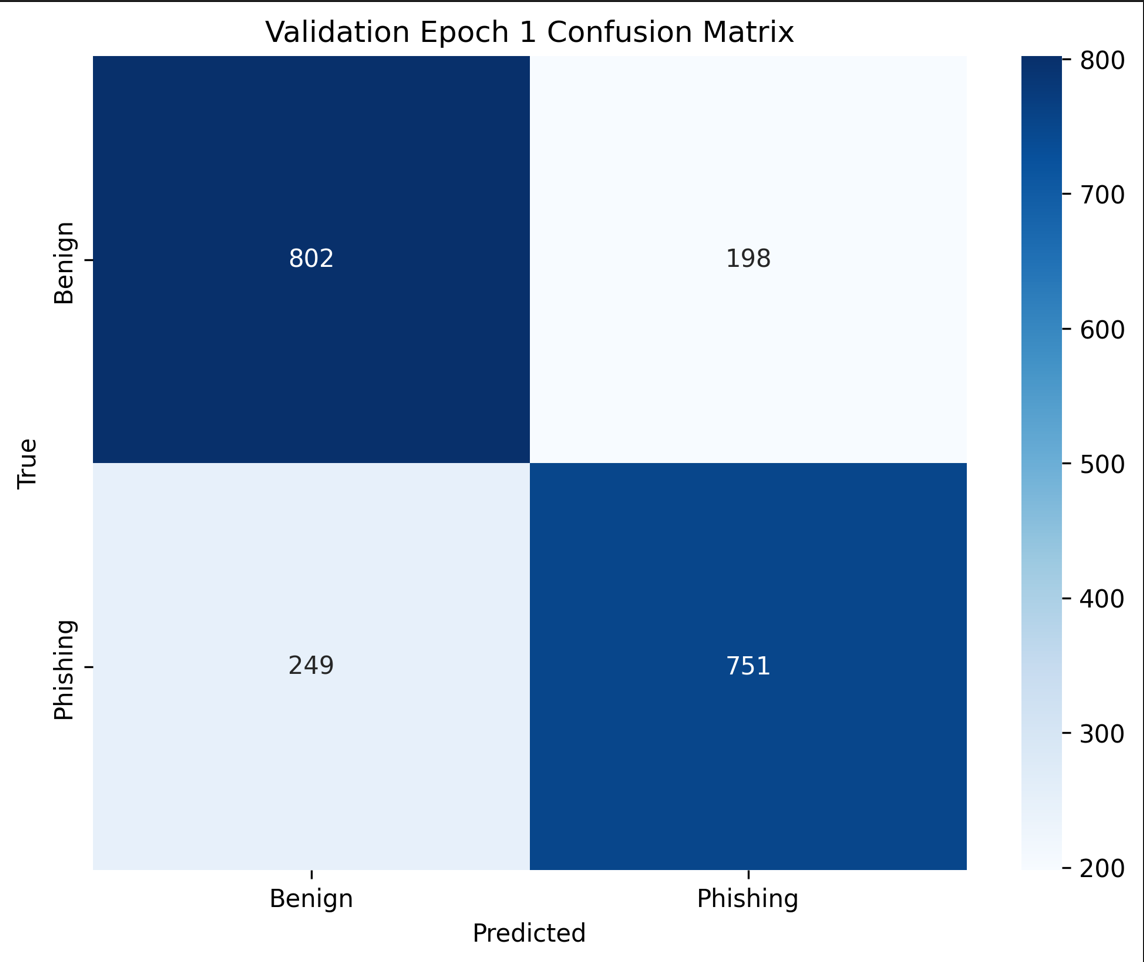

# 23. Epoch 2 Confusion Matrix

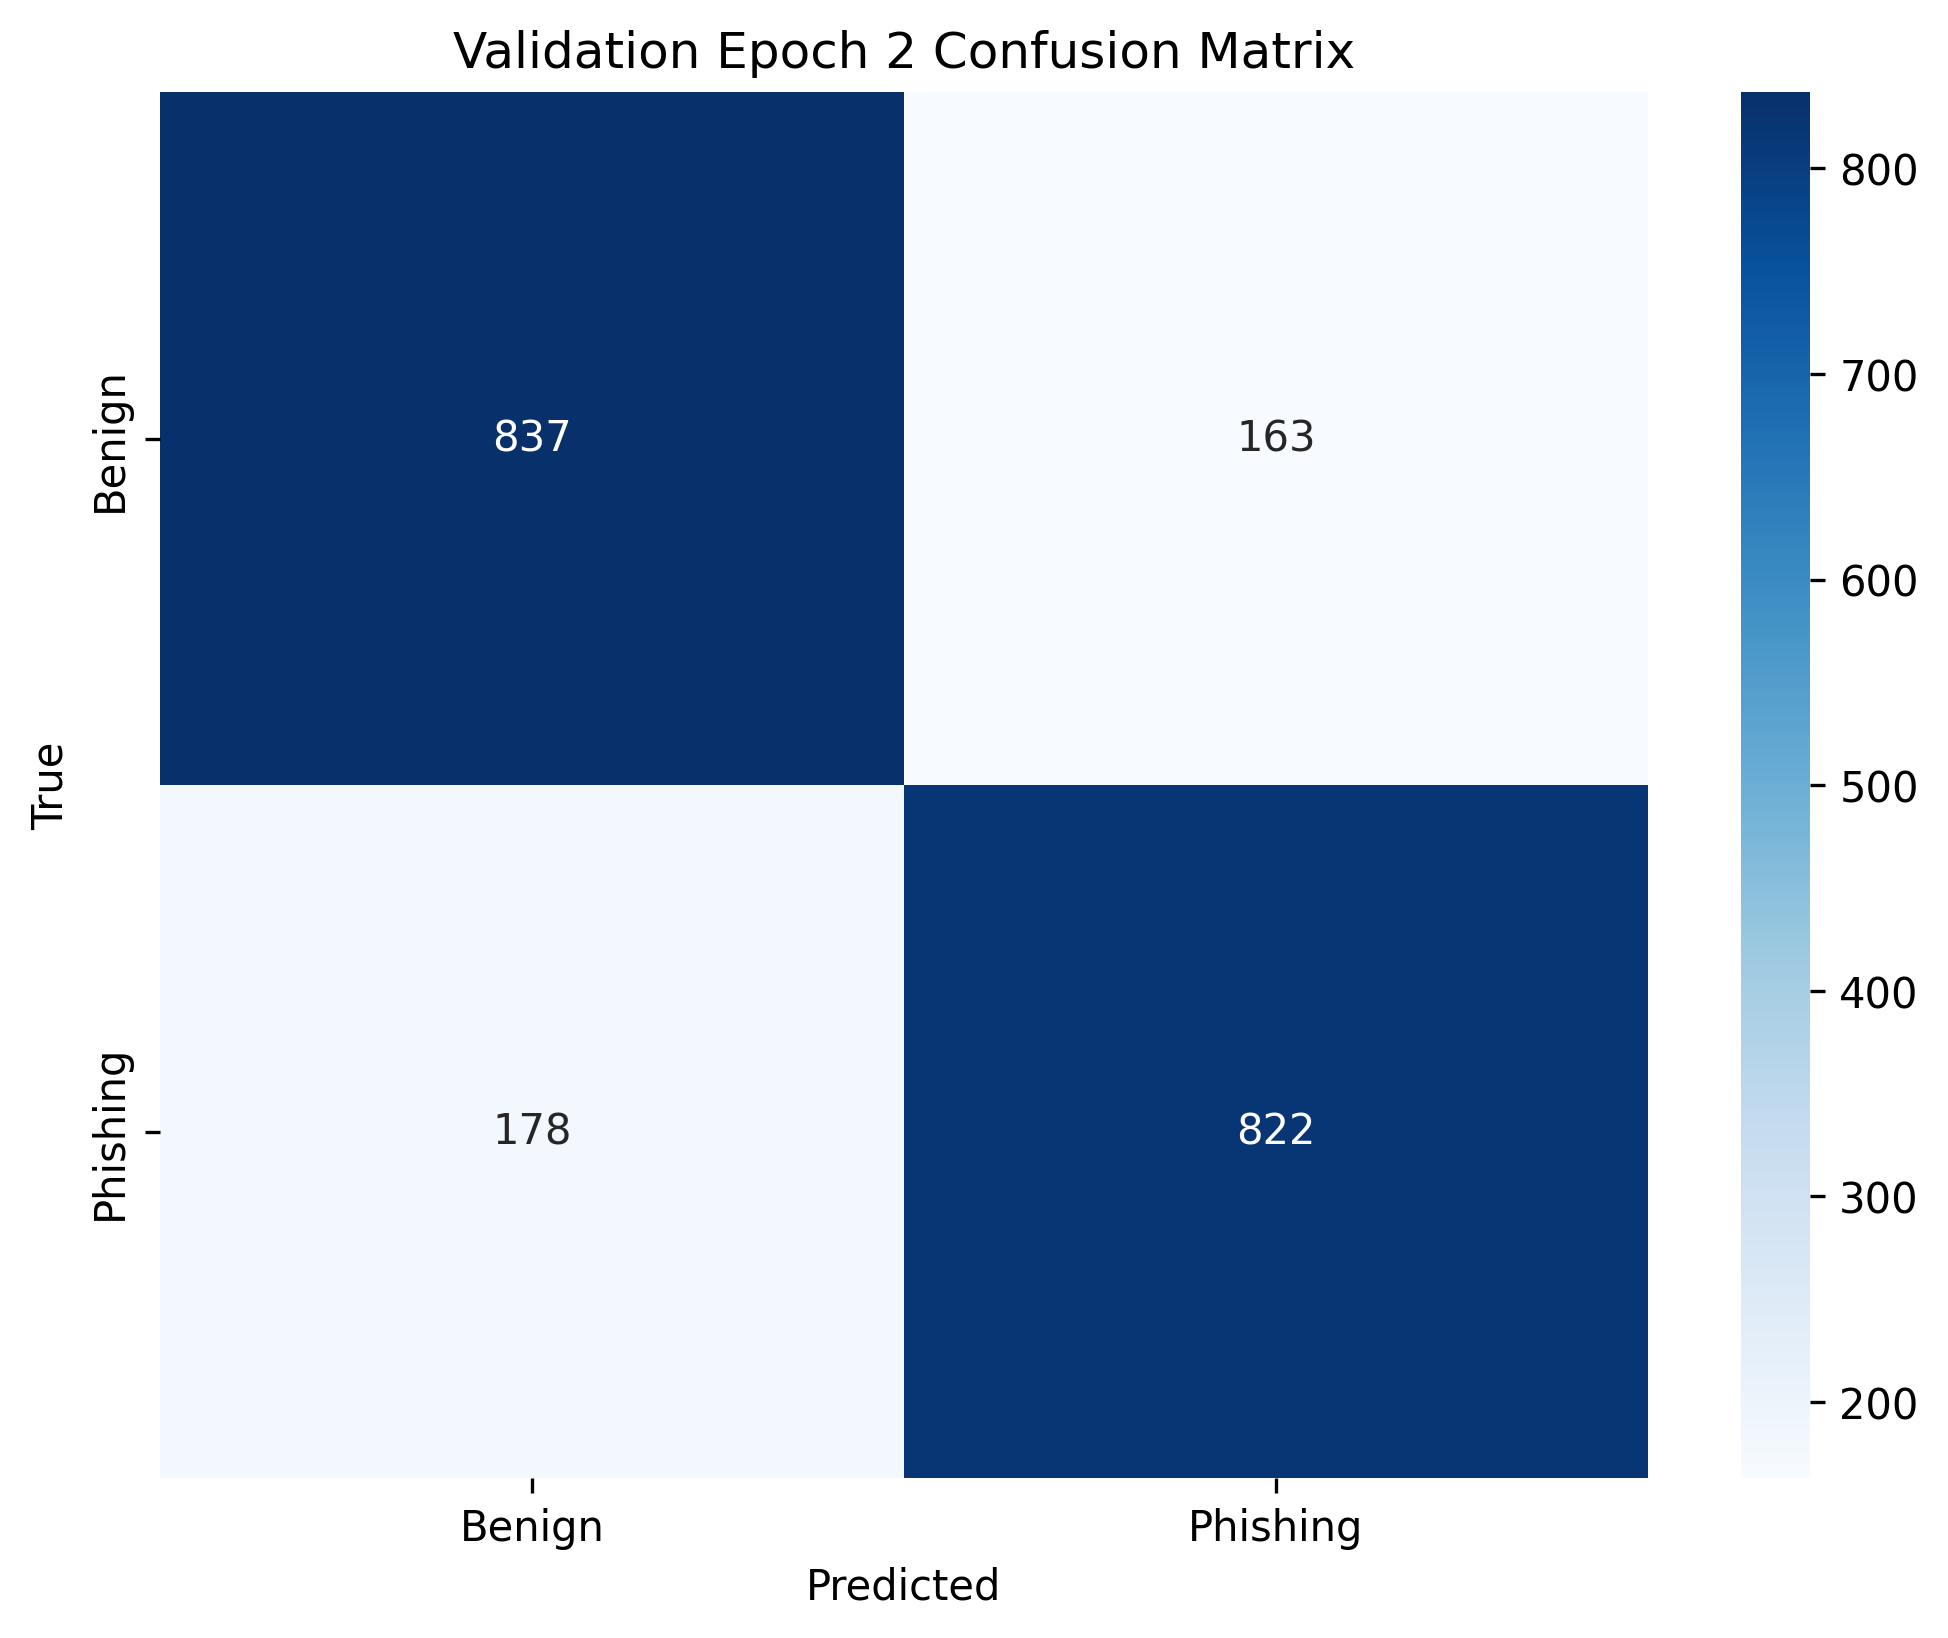

# 24. Epoch 3 Confusion Matrix

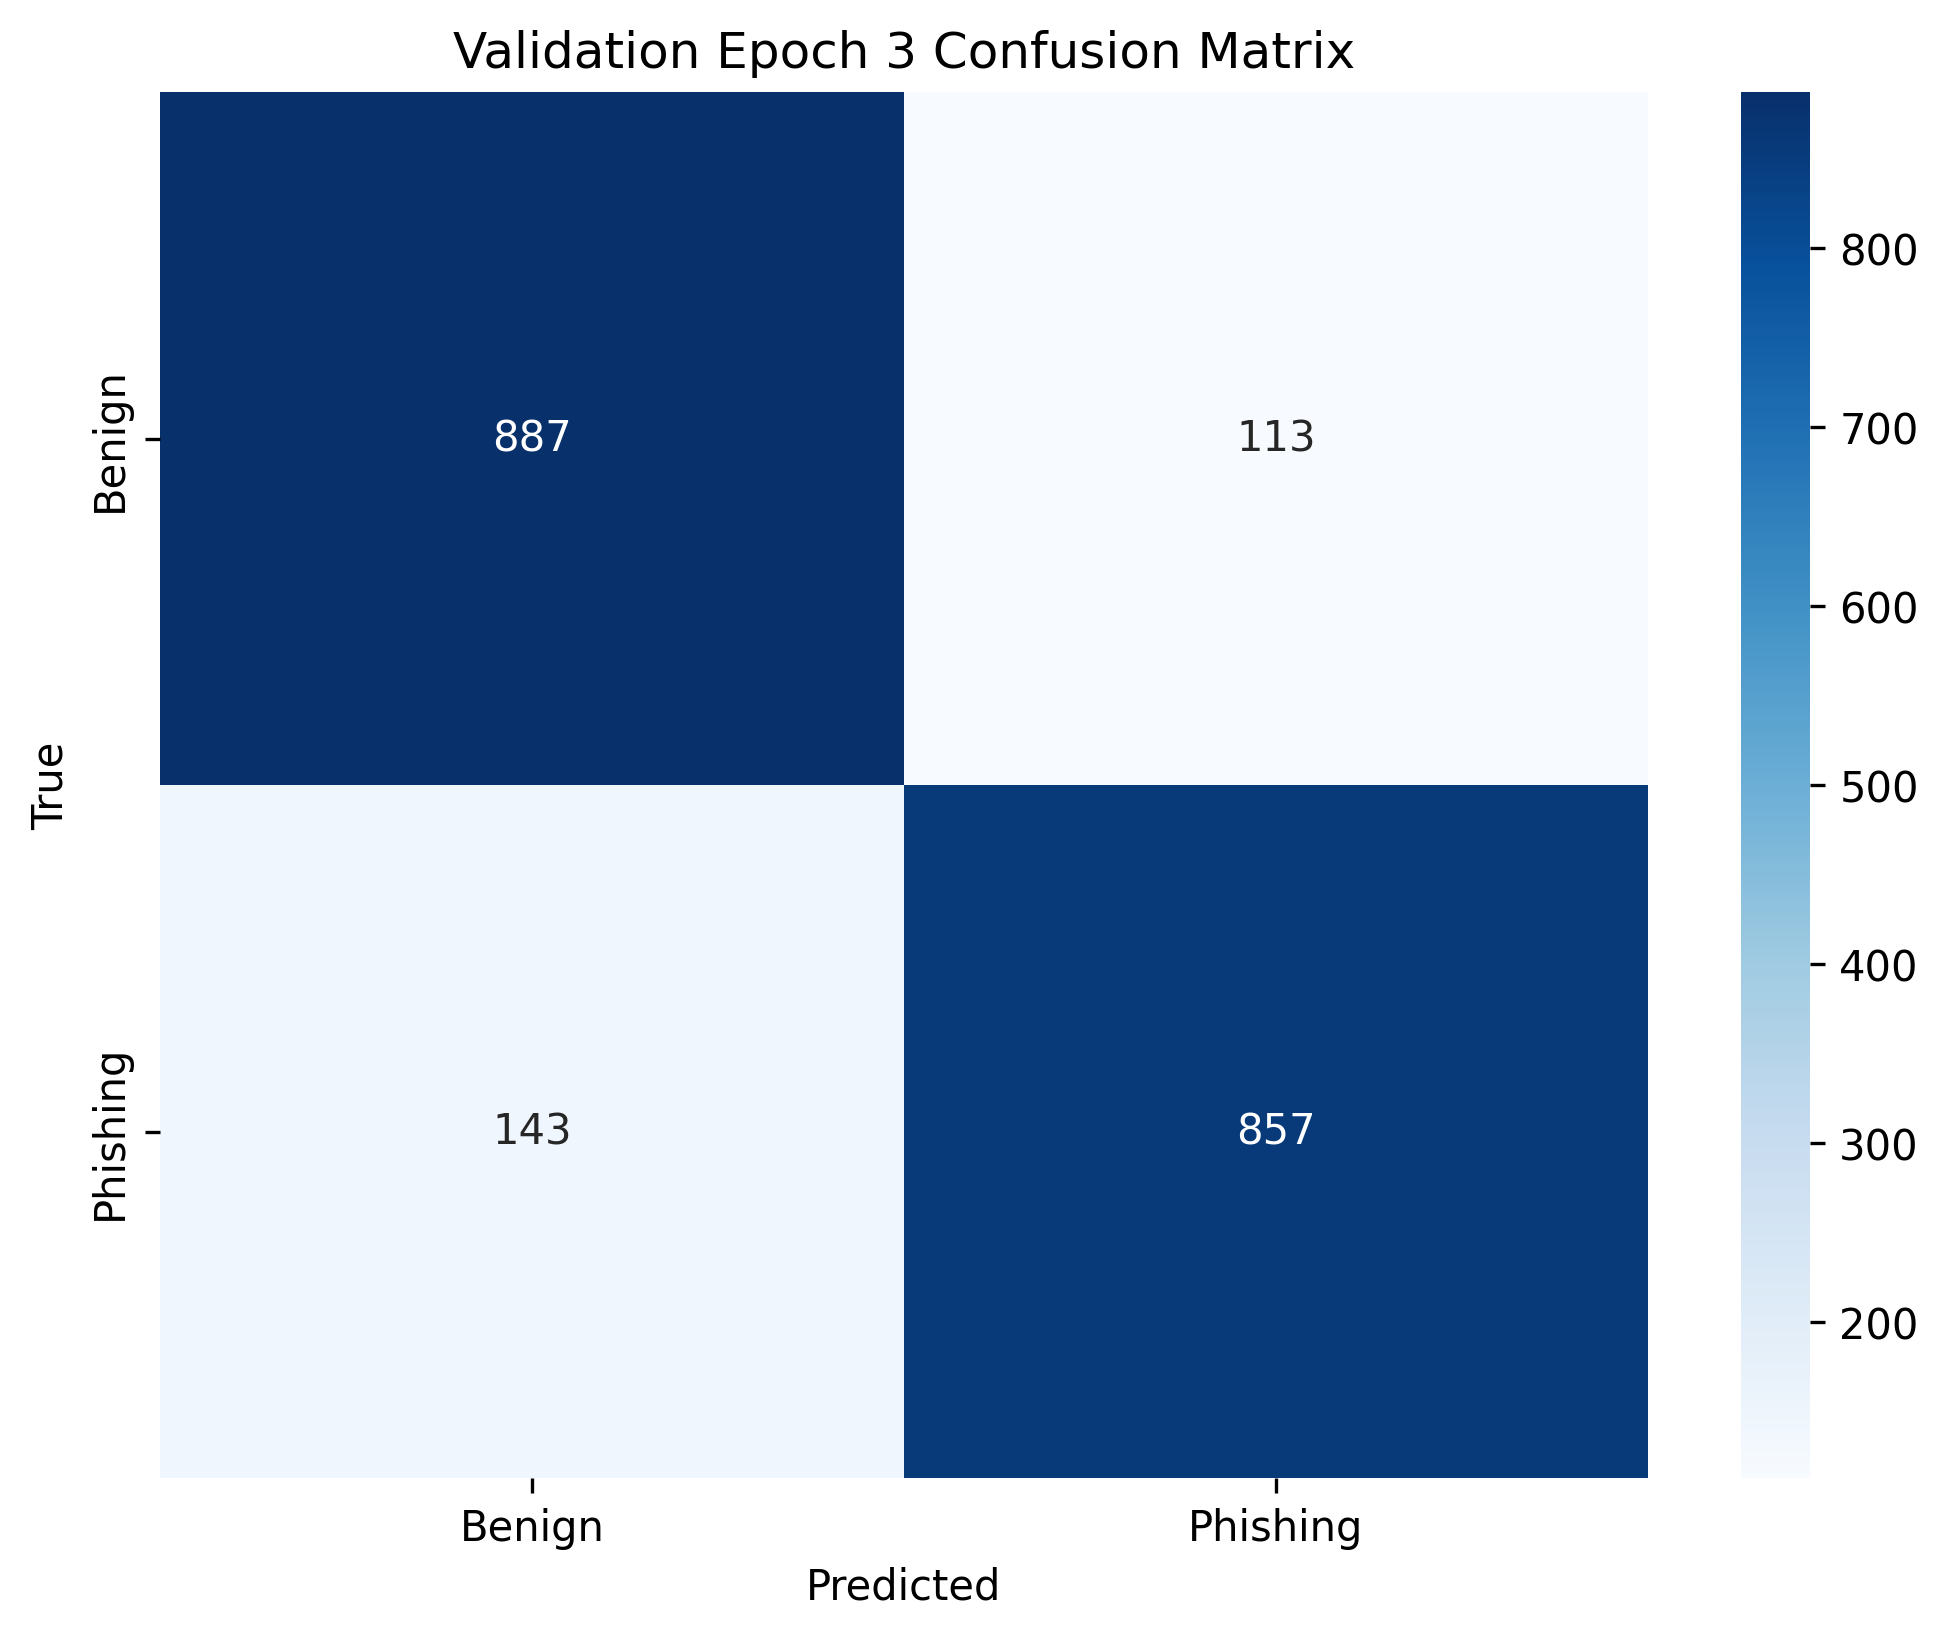

# 25. Test Evaluation — modified evaluation pipeline (enhanced loader + optimal-threshold), loads Model_MMA/MobileBERT weights and reports metrics

In [8]:
import torch
from transformers import AutoTokenizer, MobileBertForSequenceClassification # Ensure AutoTokenizer is here
from torch.utils.data import DataLoader, SequentialSampler, TensorDataset
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import csv
import re
import pandas as pd
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path # Import Path

# --- Add likely repo paths so Model_MMA can be imported if present ---
CANDIDATE_SRC_PATHS = [
    "/content/drive/MyDrive/assignment/src",
    "/content/phishlang_base/src",
    "/content/phishlang/src",
    "/content/src",
]
for p in CANDIDATE_SRC_PATHS:
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

# Try to import the original repo Model if available
Model = None
try:
    from Model_MMA import Model as _RepoModel
    Model = _RepoModel
    print("[INFO] Using Model from Model_MMA.py for evaluation")
except Exception as e:
    print(f"[WARN] Model_MMA not found: {e}\n[INFO] Will use MobileBERT fallback wrapper for evaluation.")

# Define MobileBertWrapper class again if the original Model was not found
# This is necessary for loading the state_dict if the fallback was used during training
if Model is None:
    class MobileBertWrapper(nn.Module):
        def __init__(self, num_labels=2):
            super().__init__()
            # Check if MobileBertForSequenceClassification is available
            try:
                 from transformers import MobileBertForSequenceClassification
                 self.backbone = MobileBertForSequenceClassification.from_pretrained("google/mobilebert-uncased", num_labels=num_labels)
            except ImportError:
                 raise ImportError("transformers library and MobileBertForSequenceClassification are required for MobileBertWrapper.")


        def forward(self, trio):
            input_ids, token_type_ids, attention_mask = trio
            out = self.backbone(
                input_ids=input_ids,
                token_type_ids=token_type_ids,
                attention_mask=attention_mask,
            )
            logits = out.logits
            return None, None, logits
    Model = MobileBertWrapper # Set Model to the fallback wrapper


# Enhanced data loading function (used for evaluation)
def load_csv_to_tensors_enhanced(filename, tokenizer_name="google/mobilebert-uncased", max_rows=None, pad_size=256):
    import csv # Import csv here
    from transformers import AutoTokenizer # Import AutoTokenizer here
    csv.field_size_limit(2**20)

    tok = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=True)

    try:
        df = pd.read_csv(filename, encoding="utf-8", nrows=max_rows, on_bad_lines='skip', low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(filename, encoding="latin-1", nrows=max_rows, on_bad_lines='skip', low_memory=False)

    # --- Find Text and Label Columns ---
    text_col = None
    label_col = None

    # Prioritize specific names if they exist
    if 'text_content' in df.columns:
        text_col = 'text_content'
    elif 'url' in df.columns:
        text_col = 'url'
    else:
        # Look for candidates
        cands = [c for c in df.columns if re.search(r"(url|text|content|body|parsed|src)", c, re.I)]
        if cands: text_col = cands[0]

    if '__label' in df.columns:
        label_col = '__label'
    elif 'label' in df.columns:
        label_col = 'label'
    else:
        # Look for candidates
        cands = [c for c in df.columns if re.search(r"(label|class|target|y)", c, re.I)]
        if cands: label_col = cands[0]

    # Raise error if essential columns are not found
    if text_col is None:
         raise ValueError(f"No suitable text column found in {filename}. Columns: {list(df.columns)}")
    if label_col is None:
         raise ValueError(f"No suitable label column found in {filename}. Columns: {list(df.columns)}")

    print(f"[INFO] Detected text column: '{text_col}', label column: '{label_col}'")


    # Enhanced label normalization (consistent with training)
    def normalize_label(label):
        label_str = str(label).lower().strip()
        if label_str in ['phish', 'malicious', '1', 'true', 'positive']:
            return 1
        elif label_str in ['benign', '0', 'false', 'negative']:
            return 0
        else:
            return None

    # Use the detected label_col for normalization
    df['__label_norm'] = df[label_col].apply(normalize_label)
    df = df.dropna(subset=['__label_norm'])  # Remove rows with invalid labels


    input_ids, token_types, attn_masks, labels = [], [], [], []

    for _, row in tqdm(df.iterrows(), desc=f"Tokenizing {os.path.basename(filename)}", total=len(df)):
        text = str(row[text_col]).strip() # Use detected text_col

        # Enhanced tokenization with dynamic padding/truncation
        encoding = tok(
            text,
            max_length=pad_size, # Use the pad_size parameter
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids.append(encoding['input_ids'].squeeze().tolist())
        token_types.append(encoding['token_type_ids'].squeeze().tolist())
        attn_masks.append(encoding['attention_mask'].squeeze().tolist())
        labels.append([row['__label_norm']]) # Use __label_norm

    X1 = torch.tensor(input_ids, dtype=torch.long)
    X2 = torch.tensor(token_types, dtype=torch.long)
    X3 = torch.tensor(attn_masks, dtype=torch.long)
    y = torch.tensor(labels, dtype=torch.long)

    return X1, X2, X3, y


# Evaluation helper function
def find_optimal_threshold(y_true, y_probs):
    """Find the best threshold for maximum accuracy"""
    thresholds = np.arange(0.01, 0.99, 0.01) # Search a wider range
    best_acc = -1 # Initialize with a value lower than any possible accuracy
    best_threshold = 0.5

    for threshold in thresholds:
        preds = (y_probs >= threshold).astype(int)
        # Ensure metrics are calculated even if only one class is present
        acc = accuracy_score(y_true, preds)

        if acc > best_acc:
            best_acc = acc
            best_threshold = threshold

    return best_threshold, best_acc


def evaluate_enhanced(model, device, test_loader, tag="Test"):
    model.eval()
    all_logits, all_targets = [], []
    total_loss, total_n = 0.0, 0

    with torch.no_grad():
        for b in test_loader:
            b = [t.to(device) for t in b]
            input_ids, token_type_ids, attention_mask, targets = b
            # Call the model using the wrapper's forward method
            _, _, logits = model([input_ids, token_type_ids, attention_mask])

            loss = F.cross_entropy(logits, targets.squeeze())
            total_loss += loss.item() * targets.size(0)
            total_n += targets.size(0)
            all_logits.append(logits.detach().cpu())
            all_targets.append(targets.detach().cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0).numpy()
    probs = torch.softmax(all_logits, dim=1)[:, 1].numpy() # Get probability for the positive class

    avg_loss = total_loss / total_n

    # Find optimal threshold
    optimal_threshold, optimal_acc = find_optimal_threshold(all_targets, probs)

    # Calculate metrics with optimal threshold
    preds_optimal = (probs >= optimal_threshold).astype(int)
    # Add zero_division=0 to metrics calculation
    acc_optimal = accuracy_score(all_targets, preds_optimal)
    prec_optimal = precision_score(all_targets, preds_optimal, zero_division=0)
    rec_optimal = recall_score(all_targets, preds_optimal, zero_division=0)
    f1_optimal = f1_score(all_targets, preds_optimal, zero_division=0)

    # Also calculate with default threshold (0.5) for comparison
    preds_default = (probs >= 0.5).astype(int)
    acc_default = accuracy_score(all_targets, preds_default)
    prec_default = precision_score(all_targets, preds_default, zero_division=0)
    rec_default = recall_score(all_targets, preds_default, zero_division=0)
    f1_default = f1_score(all_targets, preds_default, zero_division=0)


    # Print metrics
    print(f"{tag} set: Average loss: {avg_loss:.4f}")
    print("-" * 30)
    print(f"Metrics with Default Threshold (0.500):")
    print(f"  Accuracy: {acc_default * 100:.2f}%")
    print(f"  Precision: {prec_default * 100:.2f}%")
    print(f"  Recall: {rec_default * 100:.2f}%")
    f1_default_str = f"{f1_default * 100:.2f}%" if f1_default is not None else "N/A" # Handle potential None
    print(f"  F1 Score: {f1_default_str}")
    print("-" * 30)
    print(f"Metrics with Optimal Threshold ({optimal_threshold:.3f}):")
    print(f"  Accuracy: {acc_optimal * 100:.2f}%")
    print(f"  Precision: {prec_optimal * 100:.2f}%")
    print(f"  Recall: {rec_optimal * 100:.2f}%")
    f1_optimal_str = f"{f1_optimal * 100:.2f}%" if f1_optimal is not None else "N/A" # Handle potential None
    print(f"  F1 Score: {f1_optimal_str}")
    print("-" * 30)


    # Generate and save confusion matrix for the optimal threshold
    try:
        cm_path = "test_confusion_matrix_optimal.png"
        plot_confusion(all_targets, preds_optimal, path=cm_path, labels=['Benign', 'Phishing'])
        print(f"Confusion matrix (optimal threshold) saved to: {cm_path}")
    except Exception as e:
        print(f"Could not save confusion matrix: {e}")

    return acc_optimal, prec_optimal, rec_optimal, f1_optimal

# Add the missing plot_confusion function (needed if not globally available)
def plot_confusion(y_true, y_pred, path="confusion_matrix.png", labels=None):
    """
    Plot and save confusion matrix
    """
    if labels is None:
        labels = ['Benign', 'Phishing']

    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Create figure and plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Save the plot
    plt.savefig(path, dpi=300, bbox_inches='tight')
    # plt.show() # Avoid showing plot in non-interactive environments

    return path


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Configuration ---
TEST_CSV = "/content/drive/MyDrive/assignment/training_data/csv/D_Test.csv"
MODEL_SAVE = "/content/drive/MyDrive/assignment/training_runs/model (1).pth" # UPDATED MODEL PATH
BATCH_SIZE = 8 # Use a reasonable batch size
PAD_SIZE = 256 # Define PAD_SIZE here for load_csv_to_tensors_enhanced

# --- Check if test CSV exists ---
if not Path(TEST_CSV).exists():
    print(f"Error: Test CSV not found at {TEST_CSV}.")
    print("Please ensure D_Test.csv is created by running cells vQVjZCRxWTXI and NeM7WQRRXmKU.")
    # Optionally exit if the file is critical
    # exit(1)
else:
    # Load the model architecture (matching the training cell)
    # Use the 'Model' variable which is either the repo model or MobileBertWrapper
    model_eval = Model().to(device) # Instantiate the model class

    # Load trained weights
    map_location = device # Use device directly for map_location

    try:
        # Attempt to load the state dict
        # Ensure the state dict keys match the model architecture
        model_eval.load_state_dict(torch.load(MODEL_SAVE, map_location=map_location))
        print("Model weights loaded successfully!")
    except Exception as e:
        print(f"Error loading model weights: {e}")
        print("Please verify the path to the model file and ensure the model architecture matches the saved state_dict.")
        # Exit if model loading fails
        # exit(1)


    # Load enhanced test data using the enhanced function
    print(f"Loading test data from: {TEST_CSV}")

    try:
        # Using load_csv_to_tensors_enhanced
        # Pass the detected text and label columns to the function if needed,
        # or ensure the function finds them robustly internally.
        # The function currently finds them, but the processing needs to use them correctly.
        X1_test, X2_test, X3_test, y_test = load_csv_to_tensors_enhanced(TEST_CSV, "google/mobilebert-uncased", pad_size=PAD_SIZE) # Use the enhanced loader and pass PAD_SIZE
        print(f"Test data loaded: {X1_test.shape[0]} samples")
        test_ds = TensorDataset(X1_test, X2_test, X3_test, y_test)
        test_loader = DataLoader(test_ds, sampler=SequentialSampler(test_ds), batch_size=BATCH_SIZE)

        # Evaluate with enhanced method
        print("\n" + "="*50)
        print("Starting Test Set Evaluation")
        print("="*50)
        acc, prec, rec, f1 = evaluate_enhanced(model_eval, device, test_loader, tag="Test")

        # Print summary (already printed in evaluate_enhanced, but can add a final note)
        print("\nEvaluation complete.")

    except FileNotFoundError as e:
        print(f"Error loading test data: {e}")
        print("Please ensure the path to D_Test.csv is correct.")
    except Exception as e:
        print(f"Error during evaluation: {e}")
        import traceback
        traceback.print_exc()


# Clear GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared!")

[WARN] Model_MMA not found: No module named 'Model_MMA'
[INFO] Will use MobileBERT fallback wrapper for evaluation.
Using device: cuda


Some weights of MobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model weights loaded successfully!
Loading test data from: /content/drive/MyDrive/assignment/training_data/csv/D_Test.csv
[INFO] Detected text column: 'url', label column: 'label'


Tokenizing D_Test.csv: 100%|██████████| 10000/10000 [12:23<00:00, 13.44it/s]


Test data loaded: 10000 samples

Starting Test Set Evaluation
Test set: Average loss: 0.4314
------------------------------
Metrics with Default Threshold (0.500):
  Accuracy: 80.80%
  Precision: 59.07%
  Recall: 80.73%
  F1 Score: 68.22%
------------------------------
Metrics with Optimal Threshold (0.750):
  Accuracy: 84.49%
  Precision: 73.81%
  Recall: 60.83%
  F1 Score: 66.70%
------------------------------
Confusion matrix (optimal threshold) saved to: test_confusion_matrix_optimal.png

Evaluation complete.
GPU memory cleared!


# 26. Confusion matrix

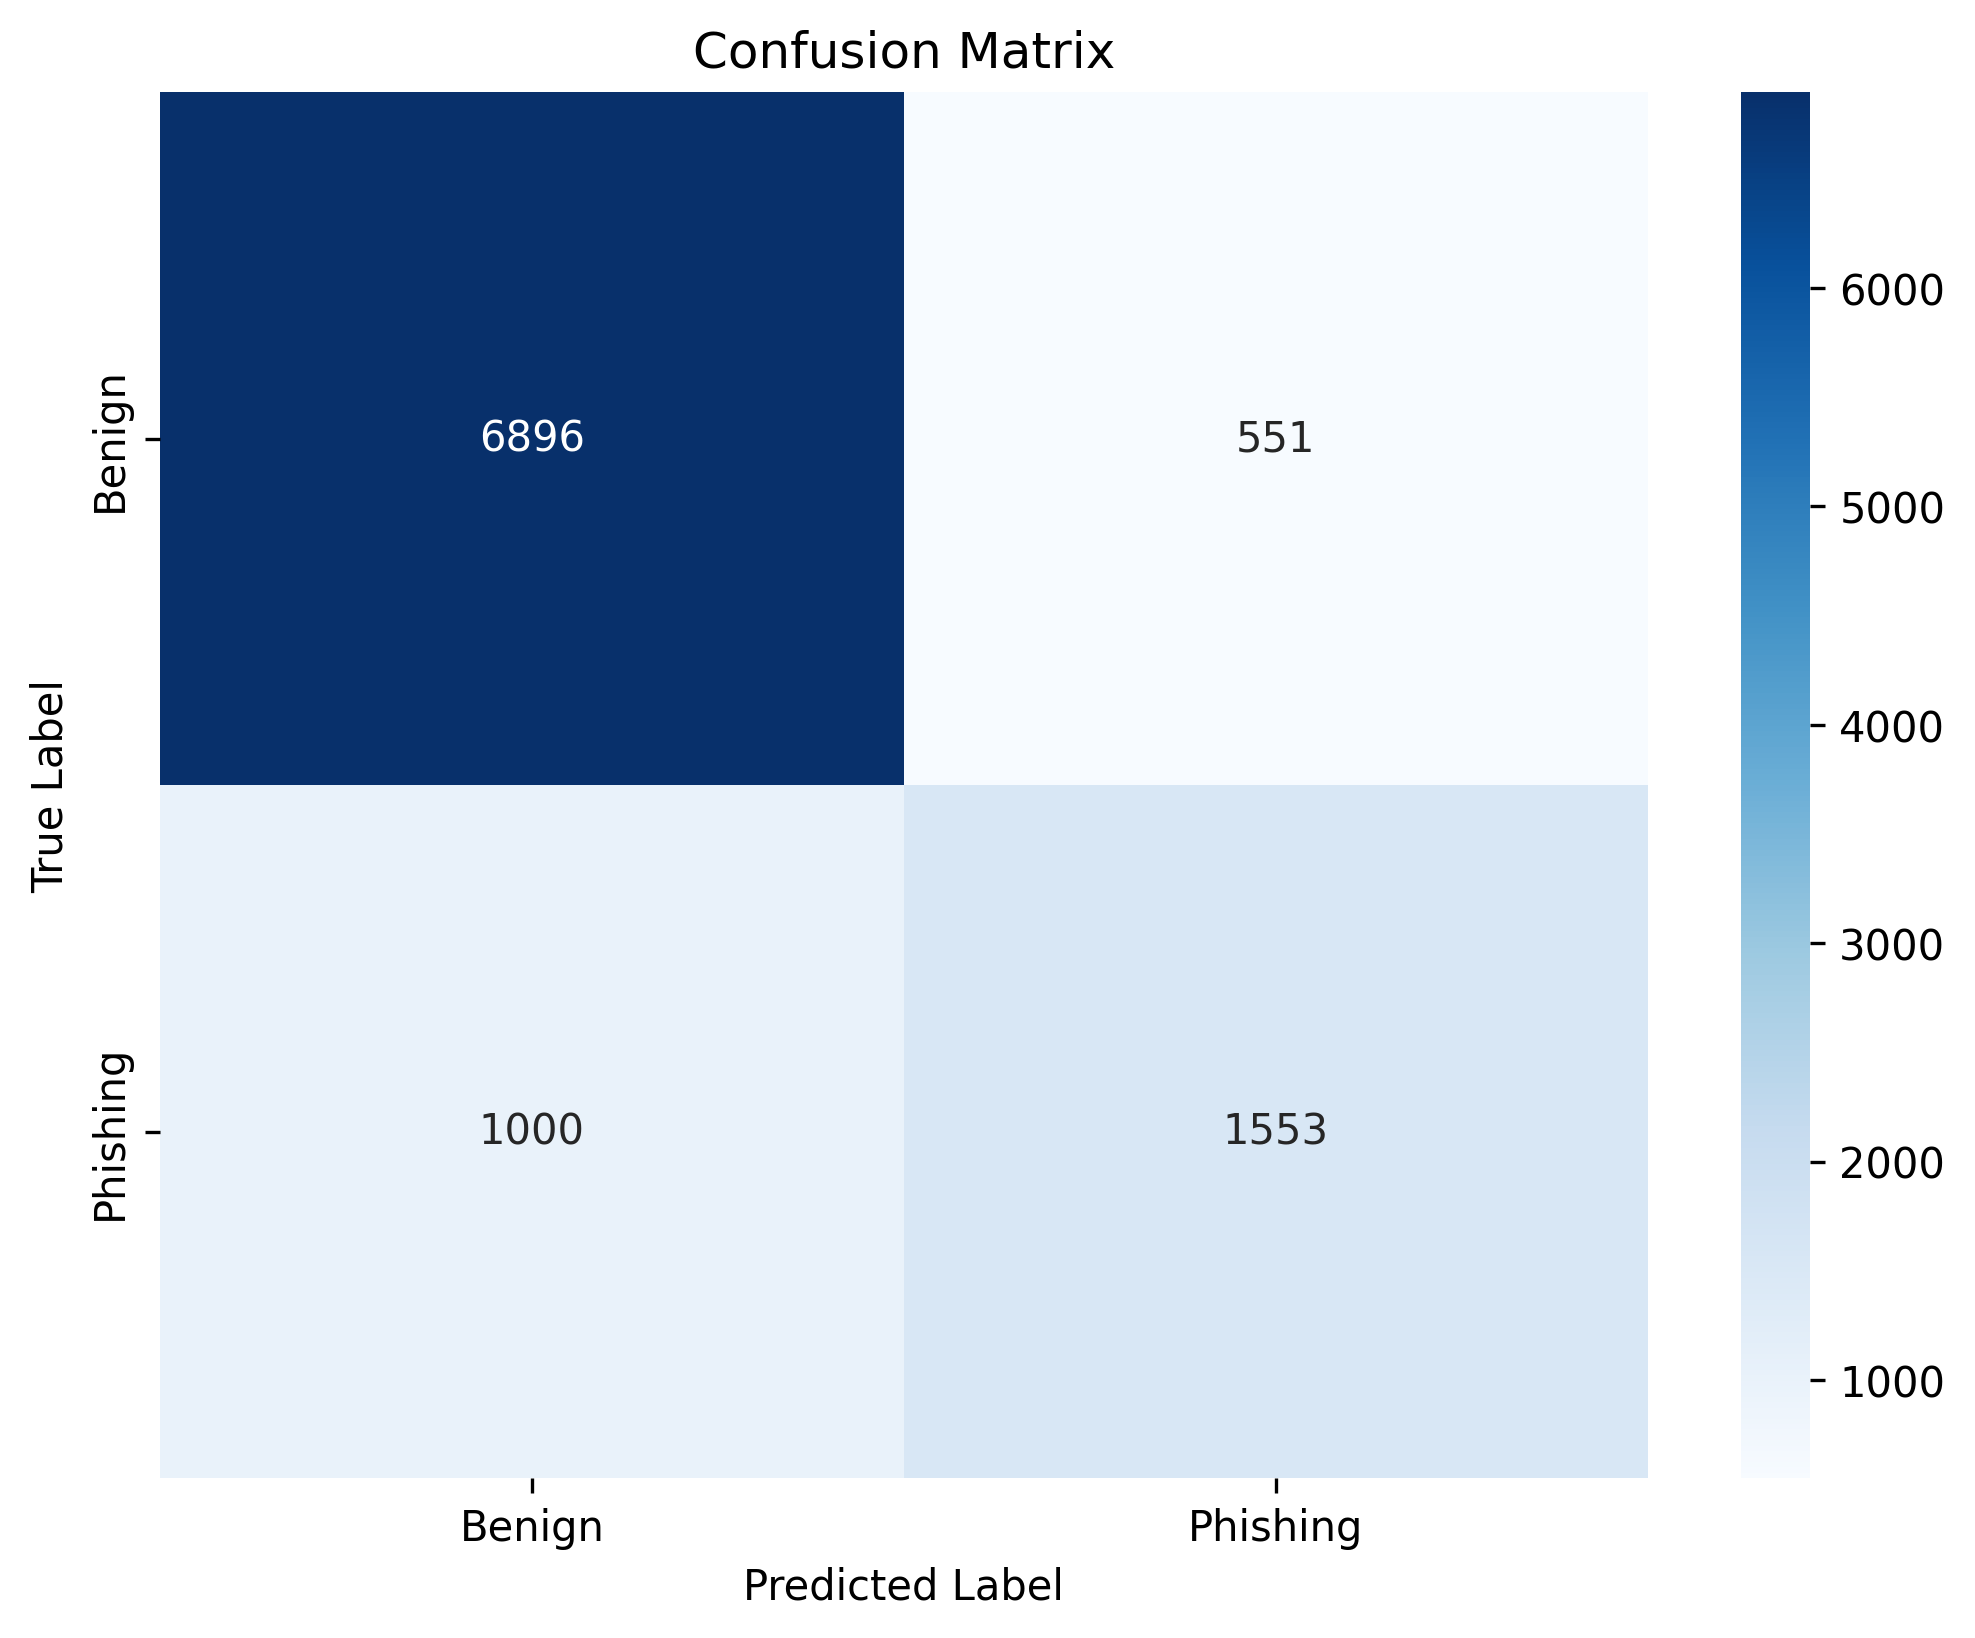